Set parameter Username
Set parameter LicenseID to value 2667226
Academic license - for non-commercial use only - expires 2026-05-16
Set parameter TimeLimit to value 1000
Set parameter MIPGap to value 0.01
Set parameter NumericFocus to value 3
Set parameter OutputFlag to value 1
Set parameter MIPFocus to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  1000
MIPGap  0.01
MIPFocus  1
NumericFocus  3

Optimize a model with 61324 rows, 43806 columns and 76890848 nonzeros
Model fingerprint: 0xdcad1260
Model has 8760 quadratic constraints
Coefficient statistics:
  Matrix range     [9e-04, 1e+03]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 6e+06]
  Bounds range     [1e+03, 1e+03]
  RHS range        [2e+05, 1e+08]
Presolve removed 4 rows and 8

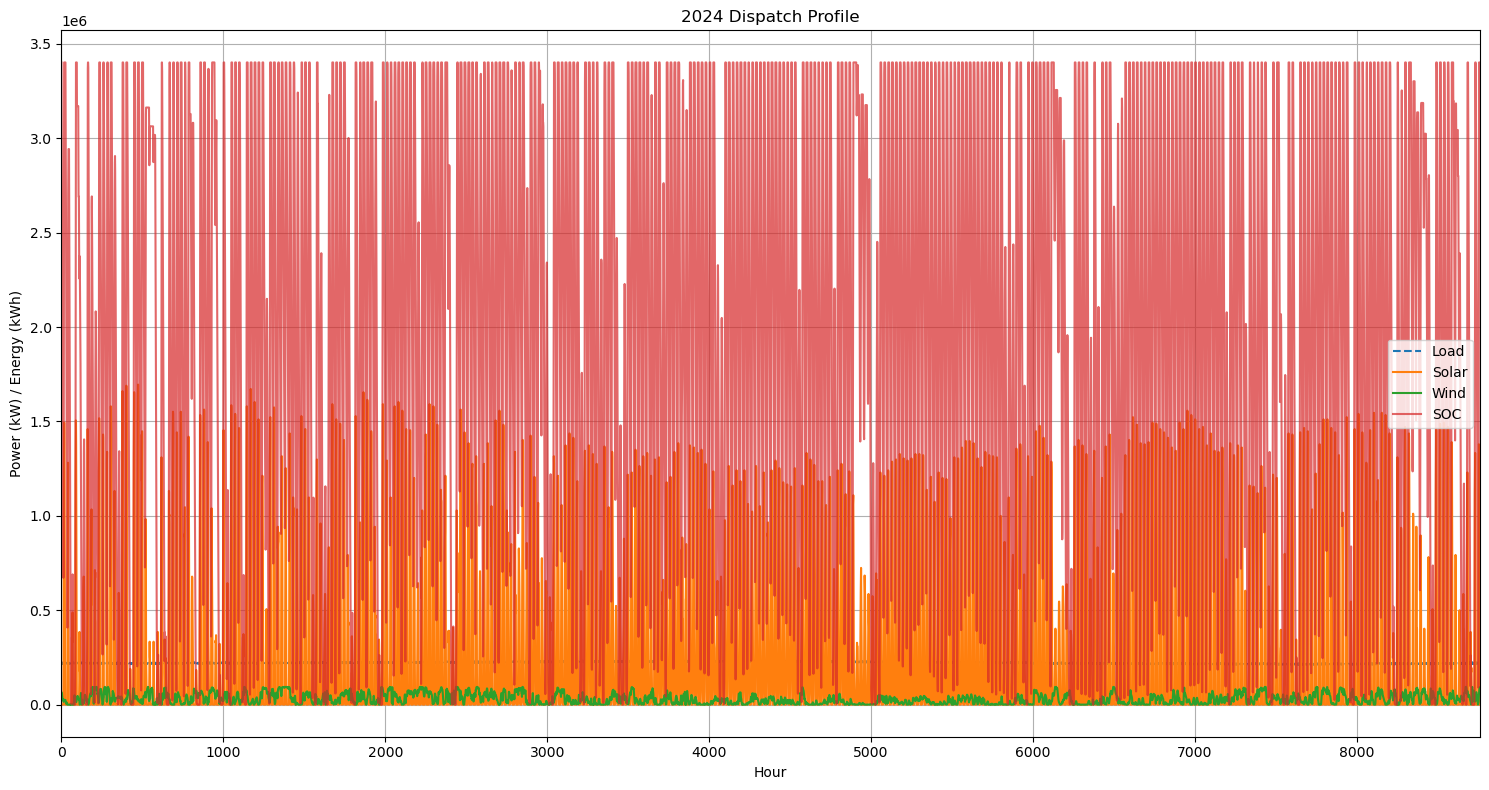

Saved dispatch data to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\dispatch_data_2024.csv
Saved hourly dispatch table to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\hourly_dispatch_2024.csv
Saved battery cycles to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\cycles_2024.csv
Saved dispatch plot to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\dispatch_profile_2024.png
Saved dispatch data to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\dispatch_data_2023.csv
Saved hourly dispatch table to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\hourly_dispatch_2023.csv
Saved battery cycles to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\cycles_2023.csv
Saved dispatch plot to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\dispatch_profile_2023.png
Saved dispatch data to dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment\dispatch_data_2022.csv
Saved hourly dispatch table to dispatch_outputs_so

In [3]:
# Clear all user-defined variables
for name in dir():
    if not name.startswith('_'):
        del globals()[name]

import gc
gc.collect()

import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import os

# === CONFIGURE ===
hours = 8760
base_power_csv = 'Desktop/base_power_profile.csv'
solar_csv_2024 = 'Desktop/Solar/2000s/ninja_pv_35.1460_-90.0518_uncorrected (0).csv'
wind_csv_2024 = 'Desktop/Wind/2000s/ninja_wind_35.1460_-90.0518_uncorrected (0).csv'
battery_efficiency = 0.89
dc_series_efficiency = 0.97 * 0.93
life_project = 15
output_dir = "dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment"  # Directory to save plots and CSVs

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === Load and Preprocess 2024 Data ===
try:
    df_base = pd.read_csv(base_power_csv)
    base_power = df_base['Power_W'].to_numpy()
except FileNotFoundError:
    print("Error: base_power_profile.csv not found.")
    exit(1)

# PUE profile
quarter_midpoints = np.linspace(0, hours, 5)
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]
hourly_pue = make_interp_spline(quarter_midpoints, pue_targets, k=3)(np.arange(hours))
dc_ac_conversion_efficiency = 0.975
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)

# 2024 Solar and wind resources
df_solar = pd.read_csv(solar_csv_2024, skiprows=3)
df_wind = pd.read_csv(wind_csv_2024, skiprows=3)
solar_vector = df_solar['electricity']
wind_vector = df_wind['electricity']
solar_resource_2024 = solar_vector[:hours]
wind_resource_2024 = wind_vector[:hours]

# === Optimization Parameters ===
inverter_capacity = (750 / 1000) * 200000 * 1.405 * (0.15 / dc_ac_conversion_efficiency)
cost_solar = 67.6 * 1.1 * 1.25
cost_wind = 5113800
cost_battery = 358
cost_inverter = 165 * 1.1 * 1.0795

om_solar = 7.965
om_wind = 93750
om_battery = 8.52
om_inverter = cost_inverter * 0.05

life_solar = 25
life_wind = 20
life_battery = 10
life_inverter = 10

unmet_load_penalty = 0
total_demand = sum(load_profile)
allowed_unmet = 0.075 * total_demand

inf = 0.023
dis = 0.045
timval = (1 + inf) / (1 + dis)

required_uptime = 0.99671
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5


# === Optimization Function ===
def run_linear_milp_optimization_gurobipy(load_profile, solar_resource, wind_resource,
                                         cost_solar, cost_wind, cost_battery,
                                         unmet_load_penalty, battery_efficiency,
                                         Ns_min, Nw_min, Nb_min):
    try:
        model = gp.Model("EnergySystem")
        
        # Variables
        solar_capacity = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="solar_capacity")
        wind_capacity = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="wind_capacity")
        battery_capacity = model.addVar(lb=1000, vtype=GRB.CONTINUOUS, name="battery_capacity")
        battery_charge = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_charge")
        battery_discharge = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_discharge")
        battery_soc = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_soc")
        unmet_load = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="unmet_load")
        curtailment = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="curtailment")

        # NPC Calculations
        discount_factor = (1 - (timval)**life_project) / (1 - timval)
        solar_capex = cost_solar * solar_capacity * Ns_min
        wind_capex = cost_wind * wind_capacity * Nw_min
        battery_capex = cost_battery * battery_capacity * Nb_min
        inverter_capex = cost_inverter * inverter_capacity * Ni_min

        solar_opex = om_solar * solar_capacity * timval * discount_factor
        wind_opex = om_wind * wind_capacity * timval * discount_factor
        battery_opex = om_battery * battery_capacity * timval * discount_factor
        inverter_opex = om_inverter * inverter_capacity * timval * discount_factor

        solar_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="solar_replacement")
        wind_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="wind_replacement")
        inverter_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="inverter_replacement")

        if life_solar >= life_project:
            model.addConstr(solar_replacement == 0)
        else:
            model.addConstr(solar_replacement == (solar_capex * (1 + inf)**life_solar) / ((1 + dis)**life_solar))

        if life_wind >= life_project:
            model.addConstr(wind_replacement == 0)
        else:
            model.addConstr(wind_replacement == (wind_capex * (1 + inf)**life_wind) / ((1 + dis)**life_wind))

        if life_inverter >= life_project:
            model.addConstr(inverter_replacement == 0)
        else:
            model.addConstr(inverter_replacement == (inverter_capex * (1 + inf)**life_inverter) / ((1 + dis)**life_inverter))

        solar_salvage = solar_capex * (life_solar - (life_project % life_solar)) / life_solar * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        wind_salvage = wind_capex * (life_wind - (life_project % life_wind)) / life_wind * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        battery_salvage = battery_capex * (life_battery - (life_project % life_battery)) / life_battery * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        inverter_salvage = inverter_capex * (life_inverter - (life_project % life_inverter)) / life_inverter * ((1 + inf)**life_project) / ((1 + dis)**life_project)

        solar_npc = solar_capex + solar_replacement - solar_salvage + solar_opex
        wind_npc = wind_capex + wind_replacement - wind_salvage + wind_opex
        battery_npc = battery_capex - battery_salvage + battery_opex
        inverter_npc = inverter_capex + inverter_replacement - inverter_salvage + inverter_opex

        # Objective
        total_cost = (
            solar_npc +
            wind_npc +
            battery_npc +
            inverter_npc +
            unmet_load_penalty * gp.quicksum(unmet_load[t] for t in range(hours))
        )
        model.setObjective(total_cost, GRB.MINIMIZE)

        # Constraints
        model.addConstr(battery_soc[0] == battery_capacity, name="initial_soc")
        for t in range(hours):
            solar_gen = solar_resource[t] * solar_capacity * dc_series_efficiency
            wind_gen = wind_resource[t] * wind_capacity * dc_series_efficiency
            net_gen = solar_gen + wind_gen
            model.addConstr(battery_soc[t] <= battery_capacity, name=f"soc_upper_{t}")
            model.addConstr(battery_charge[t] <= battery_capacity, name=f"charge_upper_{t}")
            model.addConstr(battery_discharge[t] <= battery_capacity, name=f"discharge_upper_{t}")
            model.addConstr(battery_discharge[t] <= battery_soc[t], name=f"discharge_limit_{t}")
            model.addConstr(
                net_gen + battery_discharge[t] * dc_series_efficiency -
                battery_charge[t] / battery_efficiency - curtailment[t] -
                load_profile[t] + unmet_load[t] == 0,
                name=f"energy_balance_{t}"
            )
            model.addConstr(gp.quicksum(unmet_load[t] for t in range(hours)) <= allowed_unmet, name="unmet_load_limit")
            model.addConstr(battery_charge[t] * battery_discharge[t] <= 0, name=f"no_simul_charge_discharge_{t}")
            if t > 0:
                model.addConstr(
                    battery_soc[t] == battery_soc[t-1] +
                    battery_charge[t] -
                    battery_discharge[t] / battery_efficiency,
                    name=f"soc_update_{t}"
                )
        model.addConstr(battery_soc[hours-1] >= 0 * battery_capacity, name="min_final_soc")

        model.setParam("TimeLimit", 1000)
        model.setParam("MIPGap", 0.01)
        model.setParam("NumericFocus", 3)
        model.setParam("OutputFlag", 1)
        model.setParam("MIPFocus", 1)

        model.optimize()

        if model.status == GRB.OPTIMAL:
            print("Optimal Solution Found!")
            print(f"Solar Capacity: {solar_capacity.x:.2f} PV")
            print(f"Wind Capacity: {wind_capacity.x:.2f} HAWT")
            print(f"Battery Capacity: {battery_capacity.x:.2f} kWh")
            return {
                "solar": solar_capacity.x,
                "wind": wind_capacity.x,
                "battery": battery_capacity.x,
                "cost": model.objVal,
                "solar_capex": solar_capex.getValue(),
                "solar_opex": solar_opex.getValue(),
                "solar_replacement": solar_replacement.x,
                "solar_salvage": solar_salvage.getValue(),
                "wind_capex": wind_capex.getValue(),
                "wind_opex": wind_opex.getValue(),
                "wind_replacement": wind_replacement.x,
                "wind_salvage": wind_salvage.getValue(),
                "battery_capex": battery_capex.getValue(),
                "battery_opex": battery_opex.getValue(),
                "battery_salvage": battery_salvage.getValue(),
                "inverter_capex": inverter_capex,
                "inverter_opex": inverter_opex,
                "inverter_replacement": inverter_replacement.x,
                "inverter_salvage": inverter_salvage
            }
        else:
            print(f"Optimization Failed. Status: {model.status}")
            if model.status == GRB.INFEASIBLE:
                model.computeIIS()
                model.write("conflict.ilp")
                print("IIS written to conflict.ilp")
            return {"status": model.status}

    except gp.GurobiError as e:
        print(f"Gurobi Error: {e}")
        return {"status": "error"}
    except Exception as e:
        print(f"Error: {e}")
        return {"status": "error"}

# === Degradation Function ===
def calculate_rainflow_degradation_verbose(soc_series, capacity, A=0.000144, beta=1.79, dod_threshold=0):
    soc_series = np.array(soc_series)
    total_degradation = 0.0
    cycle_info = []
    peak = soc_series[0]
    valley = peak
    direction = None
    peak_hour = 0
    valley_hour = 0

    for i in range(1, len(soc_series)):
        if soc_series[i] > soc_series[i - 1]:
            if direction == 'down':
                dod = (peak - valley) / capacity if capacity > 0 else 0
                if dod >= dod_threshold:
                    degradation = A * (dod ** beta)
                    total_degradation += degradation
                    cycle_info.append({
                        "type": "discharge",
                        "peak_hour": peak_hour,
                        "valley_hour": valley_hour,
                        "DoD": round(dod, 4),
                        "degradation": round(degradation, 6)
                    })
                peak = soc_series[i]
                peak_hour = i
                direction = 'up'
            else:
                peak = max(peak, soc_series[i])
                if peak == soc_series[i]:
                    peak_hour = i
                direction = 'up'
        elif soc_series[i] < soc_series[i - 1]:
            if direction == 'up':
                valley = soc_series[i]
                valley_hour = i
                direction = 'down'
            else:
                valley = min(valley, soc_series[i])
                if valley == soc_series[i]:
                    valley_hour = i
                direction = 'down'

    return cycle_info, total_degradation

# === Function to Calculate Battery Replacement Cost ===
def calculate_battery_replacement_cost(battery_capex, degradation, inf, dis, life_battery):
    if degradation < 1:
        replacement_yearly = (battery_capex / (1 - degradation)) - battery_capex
        print(f"${replacement_yearly:.2f} is the replacement cost each year for degradation")
    else:
        replacement_yearly = 0

    battery_replacement_npc = 0
    for t in range(1, life_project + 1):
        battery_replacement_npc += replacement_yearly * ((1 + inf) ** t) / ((1 + dis) ** t)

    return battery_replacement_npc

# === Dispatch Simulation ===
def simulate_dispatch_fixed_capacities(load_profile, solar_resource, wind_resource,
                                      fixed_solar, fixed_wind, fixed_battery,
                                      battery_efficiency=0.89, initial_soc=0):
    hours = len(load_profile)
    model = gp.Model("fixed_dispatch")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 300

    battery_charge = model.addVars(hours, lb=0, name="charge")
    battery_discharge = model.addVars(hours, lb=0, name="discharge")
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery, name="soc")
    unmet_load = model.addVars(hours, lb=0, name="unmet")
    curtailment = model.addVars(hours, lb=0, name="curtailment")

    model.addConstr(battery_soc[0] == initial_soc)

    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_series_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_series_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(battery_soc[t] <= fixed_battery)
        model.addConstr(battery_discharge[t] <= battery_soc[t])

        if t > 0:
            model.addConstr(
                battery_soc[t] == battery_soc[t - 1] +
                battery_charge[t] -
                battery_discharge[t] / battery_efficiency
            )

        model.addConstr(
            net_gen + battery_discharge[t] * dc_series_efficiency -
            battery_charge[t] / battery_efficiency - curtailment[t] -
            load_profile[t] + unmet_load[t] == 0
        )

    model.setObjective(gp.quicksum(unmet_load[t] for t in range(hours)), GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        battery_soc_vals = np.array([battery_soc[t].X for t in range(hours)])
        battery_charge_vals = np.array([battery_charge[t].X for t in range(hours)])
        battery_discharge_vals = np.array([battery_discharge[t].X for t in range(hours)])
        cycles, degradation = calculate_rainflow_degradation_verbose(battery_soc_vals, fixed_battery)

        return {
            "total_unmet": sum(unmet_load[t].X for t in range(hours)),
            "unmet_hours": [t for t in range(hours) if unmet_load[t].X > 1e-3],
            "unmet_profile": np.array([unmet_load[t].X for t in range(hours)]),
            "battery_soc": battery_soc_vals,
            "battery_charge": battery_charge_vals,
            "battery_discharge": battery_discharge_vals,
            "curtailment": np.array([curtailment[t].X for t in range(hours)]),
            "cycles": cycles,
            "degradation": degradation
        }
    else:
        return None

# === Function to Load Yearly Resources ===
def load_yearly_resources(year):
    try:
        if year >= 2000:
            idx = 2024 - year
            solar_csv = f'Desktop/Solar/2000s/ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv'
            wind_csv = f'Desktop/Wind/2000s/ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv'
        else:
            idx = year - 1900
            solar_csv = f'Desktop/Solar/1900s/ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv'
            wind_csv = f'Desktop/Wind/1900s/ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv'

        df_solar = pd.read_csv(solar_csv, skiprows=3)
        df_wind = pd.read_csv(wind_csv, skiprows=3)
        solar_vector = df_solar['electricity']
        wind_vector = df_wind['electricity']
        return solar_vector[:hours], wind_vector[:hours]
    except FileNotFoundError:
        print(f"Error: Resource files for year {year} not found.")
        return None, None

# === Function to Save Plot, CSVs, and Dispatch Text ===
def save_dispatch_output(year, dispatch_result, load_profile, solar_resource, wind_resource, fixed_solar, fixed_wind):
    df_dispatch = pd.DataFrame({
        "Hour": np.arange(hours),
        "Load (kW)": load_profile,
        "Solar (kW)": solar_resource * fixed_solar,
        "Wind (kW)": wind_resource * fixed_wind,
        "SOC (kWh)": dispatch_result["battery_soc"],
        "Charge (kW)": dispatch_result["battery_charge"],
        "Discharge (kW)": dispatch_result["battery_discharge"],
        "Unmet (kW)": dispatch_result["unmet_profile"],
        "Curtailment (kW)": dispatch_result["curtailment"]
    })

    # Save dispatch data CSV
    csv_path = os.path.join(output_dir, f"dispatch_data_{year}.csv")
    df_dispatch.to_csv(csv_path, index=False)
    print(f"Saved dispatch data to {csv_path}")

    # Save hourly dispatch table CSV
    dispatch_table_path = os.path.join(output_dir, f"hourly_dispatch_{year}.csv")
    df_dispatch.to_csv(dispatch_table_path, index=False)
    print(f"Saved hourly dispatch table to {dispatch_table_path}")

    # Save cycles CSV
    df_cycles = pd.DataFrame(dispatch_result["cycles"])
    cycles_path = os.path.join(output_dir, f"cycles_{year}.csv")
    df_cycles.to_csv(cycles_path, index=False)
    print(f"Saved battery cycles to {cycles_path}")

    # Save Plot
    plt.figure(figsize=(15, 8))
    plt.plot(df_dispatch["Hour"], df_dispatch["Load (kW)"], label="Load", linestyle='--')
    plt.plot(df_dispatch["Hour"], df_dispatch["Solar (kW)"], label="Solar")
    plt.plot(df_dispatch["Hour"], df_dispatch["Wind (kW)"], label="Wind")
    plt.plot(df_dispatch["Hour"], df_dispatch["SOC (kWh)"], label="SOC", alpha=0.7)
    plt.xlim(0, 8760)
    plt.legend()
    plt.grid(True)
    plt.title(f"Dispatch Profile for {year}")
    plt.xlabel("Hour")
    plt.ylabel("Power (kW) / Energy (kWh)")
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f"dispatch_profile_{year}.png")
    plt.savefig(plot_path)
    plt.close()
    print(f"Saved dispatch plot to {plot_path}")

    return df_dispatch, df_cycles

# === Run Optimization for 2024 ===
opt_results = run_linear_milp_optimization_gurobipy(
    load_profile, solar_resource_2024, wind_resource_2024,
    cost_solar, cost_wind, cost_battery,
    unmet_load_penalty, battery_efficiency,
    Ns_min, Nw_min, Nb_min
)

# === Process Results ===
if isinstance(opt_results, dict) and "status" not in opt_results:
    # Run dispatch simulation for 2024 (full output)
    dispatch_result = simulate_dispatch_fixed_capacities(
        load_profile=load_profile,
        solar_resource=solar_resource_2024,
        wind_resource=wind_resource_2024,
        fixed_solar=opt_results["solar"],
        fixed_wind=opt_results["wind"],
        fixed_battery=opt_results["battery"],
        initial_soc=opt_results["battery"]
    )

    if dispatch_result:
        # Calculate curtailment, generation, and percentage
        total_curtailed = np.sum(dispatch_result["curtailment"])
        solar_gen = solar_resource_2024 * opt_results["solar"] 
        wind_gen = wind_resource_2024 * opt_results["wind"] 
        total_generated = np.sum(solar_gen + wind_gen)
        total_power_consumed = total_generated-total_curtailed
        utilization_percentage = (total_power_consumed / total_generated * 100) if total_generated > 0 else 0

        # Print results
        print("\n=== 2024 Curtailment and Generation Metrics ===")
        print(f"Total Energy Curtailed: {total_curtailed:.2f} kWh")
        print(f"Total Energy Generated: {total_generated:.2f} kWh")
        print(f"Total Energy Used (along with efficiency losses): {total_power_consumed:.2f} kWh")
        print(f"Utilization Percentage: {utilization_percentage:.2f}%")
        
        # Calculate redundant capacities and costs
        solar_initial_capacity = opt_results["solar"]
        wind_initial_capacity = opt_results["wind"]
        battery_initial_capacity = opt_results["battery"]
        inverter_initial_capacity = inverter_capacity

        solar_initial_cost = cost_solar * solar_initial_capacity
        wind_initial_cost = cost_wind * wind_initial_capacity
        battery_initial_cost = cost_battery * battery_initial_capacity
        inverter_initial_cost = cost_inverter * inverter_initial_capacity

        solar_redundant_capacity = (Ns_min - 1) * opt_results["solar"]
        wind_redundant_capacity = (Nw_min - 1) * opt_results["wind"]
        battery_redundant_capacity = (Nb_min - 1) * opt_results["battery"]
        inverter_redundant_capacity = inverter_capacity * (Ni_min-1)

        solar_redundant_cost = cost_solar * solar_redundant_capacity
        wind_redundant_cost = cost_wind * wind_redundant_capacity
        battery_redundant_cost = cost_battery * battery_redundant_capacity
        inverter_redundant_cost = cost_inverter * inverter_redundant_capacity
        
        # Calculate battery replacement cost
        yearly_degradation = dispatch_result["degradation"]
        battery_replacement = calculate_battery_replacement_cost(
            battery_capex=opt_results["battery_capex"],
            degradation=yearly_degradation,
            inf=inf,
            dis=dis,
            life_battery=life_battery
        )

        # Update total NPC
        total_npc = opt_results["cost"] + battery_replacement

        # Display initial capacities and costs
        print("\nRedundant Capacities and Costs:")
        print(f"Solar Initial Capacity: {solar_initial_capacity:.2f} PV")
        print(f"Solar Initial Cost:    ${solar_initial_cost:.2f}")
        print(f"Wind Initial Capacity: {wind_initial_capacity:.2f} HAWT")
        print(f"Wind Initial Cost:     ${wind_initial_cost:.2f}")
        print(f"Battery Initial Capacity: {battery_initial_capacity:.2f} kWh")
        print(f"Battery Initial Cost:  ${battery_initial_cost:.2f}")
        print(f"Inverter Initial Capacity: {inverter_initial_capacity:.2f} kW")
        print(f"Inverter Initial Cost:  ${inverter_initial_cost:.2f}")

        # Display redundant capacities and costs
        print("\nRedundant Capacities and Costs:")
        print(f"Solar Redundant Capacity: {solar_redundant_capacity:.2f} PV")
        print(f"Solar Redundant Cost:    ${solar_redundant_cost:.2f}")
        print(f"Wind Redundant Capacity: {wind_redundant_capacity:.2f} HAWT")
        print(f"Wind Redundant Cost:     ${wind_redundant_cost:.2f}")
        print(f"Battery Redundant Capacity: {battery_redundant_capacity:.2f} kWh")
        print(f"Battery Redundant Cost:  ${battery_redundant_cost:.2f}")
        print(f"Inverter Redundant Capacity: {inverter_redundant_capacity:.2f} kW")
        print(f"Inverter Redundant Cost:  ${inverter_redundant_cost:.2f}")

        # Display cost breakdown
        print("\nCost Breakdown:")
        print(f"Solar CAPEX:        ${opt_results['solar_capex']:.2f}")
        print(f"Solar OPEX:         ${opt_results['solar_opex']:.2f}")
        print(f"Solar Replacement:  ${opt_results['solar_replacement']:.2f}")
        print(f"Solar Salvage:     -${opt_results['solar_salvage']:.2f}")
        print(f"Wind CAPEX:         ${opt_results['wind_capex']:.2f}")
        print(f"Wind OPEX:          ${opt_results['wind_opex']:.2f}")
        print(f"Wind Replacement:   ${opt_results['wind_replacement']:.2f}")
        print(f"Wind Salvage:      -${opt_results['wind_salvage']:.2f}")
        print(f"Battery CAPEX:      ${opt_results['battery_capex']:.2f}")
        print(f"Battery OPEX:       ${opt_results['battery_opex']:.2f}")
        print(f"Battery Replacement:${battery_replacement:.2f}")
        print(f"Battery Salvage:   -${opt_results['battery_salvage']:.2f}")
        print(f"Inverter CAPEX:     ${opt_results['inverter_capex']:.2f}")
        print(f"Inverter OPEX:      ${opt_results['inverter_opex']:.2f}")
        print(f"Inverter Replacement:${opt_results['inverter_replacement']:.2f}")
        print(f"Inverter Salvage:   -${opt_results['inverter_salvage']:.2f}")
        print(f"Total NPC:          ${total_npc:.2f}")

        print("\n=== 2024 Results ===")
        print(f"Total Unmet Load: {dispatch_result['total_unmet']:.2f} kWh")
        print(f"Hours with Unmet Load: {dispatch_result['unmet_hours']}")
        print("\nDetected Battery Cycles:")
        df_cycles = pd.DataFrame(dispatch_result["cycles"])
        print(df_cycles.to_string(index=False))
        print(f"\nTotal Estimated Degradation: {dispatch_result['degradation']:.6f}")

        df_dispatch, df_cycles = save_dispatch_output(
            year=2024,
            dispatch_result=dispatch_result,
            load_profile=load_profile,
            solar_resource=solar_resource_2024,
            wind_resource=wind_resource_2024,
            fixed_solar=opt_results["solar"],
            fixed_wind=opt_results["wind"]
        )

        # Display plot for 2024
        plt.figure(figsize=(15, 8))
        plt.plot(df_dispatch["Hour"], df_dispatch["Load (kW)"], label="Load", linestyle='--')
        plt.plot(df_dispatch["Hour"], df_dispatch["Solar (kW)"], label="Solar")
        plt.plot(df_dispatch["Hour"], df_dispatch["Wind (kW)"], label="Wind")
        plt.plot(df_dispatch["Hour"], df_dispatch["SOC (kWh)"], label="SOC", alpha=0.7)
        plt.xlim(0, 8760)
        plt.legend()
        plt.grid(True)
        plt.title("2024 Dispatch Profile")
        plt.xlabel("Hour")
        plt.ylabel("Power (kW) / Energy (kWh)")
        plt.tight_layout()
        plt.show()

        # === Evaluate Unmet Load for All Years ===
        unmet_loads = {}
        for year in range(2024, 1979, -1):
            solar_resource, wind_resource = load_yearly_resources(year)
            if solar_resource is None or wind_resource is None:
                unmet_loads[year] = None
                continue

            dispatch_result = simulate_dispatch_fixed_capacities(
                load_profile=load_profile,
                solar_resource=solar_resource,
                wind_resource=wind_resource,
                fixed_solar=opt_results["solar"],
                fixed_wind=opt_results["wind"],
                fixed_battery=opt_results["battery"],
                initial_soc=opt_results["battery"]
            )

            if dispatch_result:
                unmet_loads[year] = dispatch_result["total_unmet"]
                save_dispatch_output(
                    year=year,
                    dispatch_result=dispatch_result,
                    load_profile=load_profile,
                    solar_resource=solar_resource,
                    wind_resource=wind_resource,
                    fixed_solar=opt_results["solar"],
                    fixed_wind=opt_results["wind"]
                )
            else:
                unmet_loads[year] = None

        # === Display Unmet Load Results ===
        print("\n=== Unmet Load Across Years ===")
        valid_unmet_loads = []
        for year in range(2024, 1979, -1):
            if unmet_loads[year] is not None:
                print(f"Year {year}: Unmet Load = {unmet_loads[year]:.2f} kWh")
                valid_unmet_loads.append(unmet_loads[year])
            else:
                print(f"Year {year}: Unmet Load = Failed (missing data or optimization error)")

        if valid_unmet_loads:
            avg_unmet = np.mean(valid_unmet_loads)
            print(f"\nAverage Unmet Load (1979-2024): {avg_unmet:.2f} kWh")
            print(f"Min Unmet Load: {min(valid_unmet_loads):.2f} kWh (Year {min((year for year, val in unmet_loads.items() if val == min(valid_unmet_loads)), default='N/A')})")
            print(f"Max Unmet Load: {max(valid_unmet_loads):.2f} kWh (Year {max((year for year, val in unmet_loads.items() if val == max(valid_unmet_loads)), default='N/A')})")
        else:
            print("\nNo valid unmet load data available.")

        # === Save Capacity, Cost, and Utilization Metrics for All Years ===
        print("Starting capacity, cost, and utilization metrics collection...")
        results_by_year = []
        for year in range(2024, 1979, -1):
            print(f"Processing year {year} for capacity, cost, and utilization metrics...")
            solar_resource, wind_resource = load_yearly_resources(year)
            if solar_resource is None or wind_resource is None:
                print(f"Year {year}: Skipping due to missing resource data.")
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": None,
                    "Wind_Capacity_HAWT": None,
                    "Battery_Capacity_kWh": None,
                    "Inverter_Capacity_kW": None,
                    "Solar_CAPEX": None,
                    "Solar_OPEX": None,
                    "Solar_Replacement": None,
                    "Solar_Salvage": None,
                    "Wind_CAPEX": None,
                    "Wind_OPEX": None,
                    "Wind_Replacement": None,
                    "Wind_Salvage": None,
                    "Battery_CAPEX": None,
                    "Battery_OPEX": None,
                    "Battery_Replacement": None,
                    "Battery_Salvage": None,
                    "Inverter_CAPEX": None,
                    "Inverter_OPEX": None,
                    "Inverter_Replacement": None,
                    "Inverter_Salvage": None,
                    "Total_NPC": None,
                    "Utilization_Percentage": None,
                    "Total_Curtailed_kWh": None,
                    "Total_Generated_kWh": None,
                    "Total_Power_Consumed_kWh": None,
                    "Total_Unmet_kWh": None
                })
                continue

            dispatch_result = simulate_dispatch_fixed_capacities(
                load_profile=load_profile,
                solar_resource=solar_resource,
                wind_resource=wind_resource,
                fixed_solar=opt_results["solar"],
                fixed_wind=opt_results["wind"],
                fixed_battery=opt_results["battery"],
                initial_soc=opt_results["battery"]
            )

            if dispatch_result:
                print(f"Year {year}: Dispatch simulation successful, calculating metrics...")
                # Calculate utilization metrics
                total_curtailed = np.sum(dispatch_result["curtailment"])
                solar_gen = solar_resource * opt_results["solar"]
                wind_gen = wind_resource * opt_results["wind"]
                total_generated = np.sum(solar_gen + wind_gen)
                total_power_consumed = total_generated - total_curtailed
                utilization_percentage = (total_power_consumed / total_generated * 100) if total_generated > 0 else 0

                # Calculate battery replacement cost
                yearly_degradation = dispatch_result["degradation"]
                battery_replacement = calculate_battery_replacement_cost(
                    battery_capex=opt_results["battery_capex"],
                    degradation=yearly_degradation,
                    inf=inf,
                    dis=dis,
                    life_battery=life_battery
                )

                # Calculate total NPC
                total_npc = (
                    opt_results["solar_capex"] +
                    opt_results["solar_opex"] +
                    opt_results["solar_replacement"] -
                    opt_results["solar_salvage"] +
                    opt_results["wind_capex"] +
                    opt_results["wind_opex"] +
                    opt_results["wind_replacement"] -
                    opt_results["wind_salvage"] +
                    opt_results["battery_capex"] +
                    opt_results["battery_opex"] +
                    battery_replacement -
                    opt_results["battery_salvage"] +
                    opt_results["inverter_capex"] +
                    opt_results["inverter_opex"] +
                    opt_results["inverter_replacement"] -
                    opt_results["inverter_salvage"]
                )

                # Store results
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": opt_results["solar"],
                    "Wind_Capacity_HAWT": opt_results["wind"],
                    "Battery_Capacity_kWh": opt_results["battery"],
                    "Inverter_Capacity_kW": inverter_capacity,
                    "Solar_CAPEX": opt_results["solar_capex"],
                    "Solar_OPEX": opt_results["solar_opex"],
                    "Solar_Replacement": opt_results["solar_replacement"],
                    "Solar_Salvage": opt_results["solar_salvage"],
                    "Wind_CAPEX": opt_results["wind_capex"],
                    "Wind_OPEX": opt_results["wind_opex"],
                    "Wind_Replacement": opt_results["wind_replacement"],
                    "Wind_Salvage": opt_results["wind_salvage"],
                    "Battery_CAPEX": opt_results["battery_capex"],
                    "Battery_OPEX": opt_results["battery_opex"],
                    "Battery_Replacement": battery_replacement,
                    "Battery_Salvage": opt_results["battery_salvage"],
                    "Inverter_CAPEX": opt_results["inverter_capex"],
                    "Inverter_OPEX": opt_results["inverter_opex"],
                    "Inverter_Replacement": opt_results["inverter_replacement"],
                    "Inverter_Salvage": opt_results["inverter_salvage"],
                    "Total_NPC": total_npc,
                    "Utilization_Percentage": utilization_percentage,
                    "Total_Curtailed_kWh": total_curtailed,
                    "Total_Generated_kWh": total_generated,
                    "Total_Power_Consumed_kWh": total_power_consumed,
                    "Total_Unmet_kWh": dispatch_result["total_unmet"]
                })
                print(f"Year {year}: Metrics added - Utilization: {utilization_percentage:.2f}%, NPC: {total_npc:.2f}, Unmet: {dispatch_result['total_unmet']:.2f} kWh")
            else:
                print(f"Year {year}: Metrics save failed due to dispatch simulation error.")
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": None,
                    "Wind_Capacity_HAWT": None,
                    "Battery_Capacity_kWh": None,
                    "Inverter_Capacity_kW": None,
                    "Solar_CAPEX": None,
                    "Solar_OPEX": None,
                    "Solar_Replacement": None,
                    "Solar_Salvage": None,
                    "Wind_CAPEX": None,
                    "Wind_OPEX": None,
                    "Wind_Replacement": None,
                    "Wind_Salvage": None,
                    "Battery_CAPEX": None,
                    "Battery_OPEX": None,
                    "Battery_Replacement": None,
                    "Battery_Salvage": None,
                    "Inverter_CAPEX": None,
                    "Inverter_OPEX": None,
                    "Inverter_Replacement": None,
                    "Inverter_Salvage": None,
                    "Total_NPC": None,
                    "Utilization_Percentage": None,
                    "Total_Curtailed_kWh": None,
                    "Total_Generated_kWh": None,
                    "Total_Power_Consumed_kWh": None,
                    "Total_Unmet_kWh": None
                })

        # Save results to CSV
        try:
            df_results = pd.DataFrame(results_by_year)
            csv_path = os.path.join(output_dir, "capacity_and_costs_by_year.csv")
            df_results.to_csv(csv_path, index=False)
            print(f"Saved capacity, cost, and utilization metrics to {csv_path}")
            print(f"CSV file location: {os.path.abspath(csv_path)}")
        except Exception as e:
            print(f"Error saving CSV: {e}")

        # === Plot NPC Variation Across Years ===
        print("Starting NPC variation plotting...")
        try:
            valid_npc_data = df_results[df_results["Total_NPC"].notna()][["Year", "Total_NPC"]]
            if valid_npc_data.empty:
                print("Error: No valid NPC data found for plotting.")
            else:
                plt.figure(figsize=(15, 8))
                plt.plot(valid_npc_data["Year"], valid_npc_data["Total_NPC"], marker='o', linestyle='-', color='b')
                plt.title("NPC Variation Across Years (1979-2024)")
                plt.xlabel("Year")
                plt.ylabel("Total NPC ($)")
                plt.grid(True)
                plt.gca().invert_xaxis()  # Reverse x-axis to show 2024 to 1979
                plt.tight_layout()
                plot_path = os.path.join(output_dir, "npc_variation_by_year.png")
                plt.savefig(plot_path)
                plt.close()
                print(f"Saved NPC variation plot to {plot_path}")
                print(f"Plot file location: {os.path.abspath(plot_path)}")
        except Exception as e:
            print(f"Error plotting NPC variation: {e}")

    else:
        print("Dispatch simulation for 2024 failed.")
else:
    print("Optimization for 2024 failed.")

Set parameter TimeLimit to value 1000
Set parameter MIPGap to value 0.01
Set parameter NumericFocus to value 3
Set parameter OutputFlag to value 1
Set parameter MIPFocus to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  1000
MIPGap  0.01
MIPFocus  1
NumericFocus  3

Optimize a model with 61324 rows, 43806 columns and 76890848 nonzeros
Model fingerprint: 0xd5dad653
Model has 8760 quadratic constraints
Coefficient statistics:
  Matrix range     [9e-04, 1e+03]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 6e+06]
  Bounds range     [1e+03, 1e+03]
  RHS range        [2e+05, 2e+08]
Presolve removed 4 rows and 8763 columns (presolve time = 7s)...
Presolve removed 17525 rows and 8764 columns

Continuous model is non-convex -- solving as a MIP

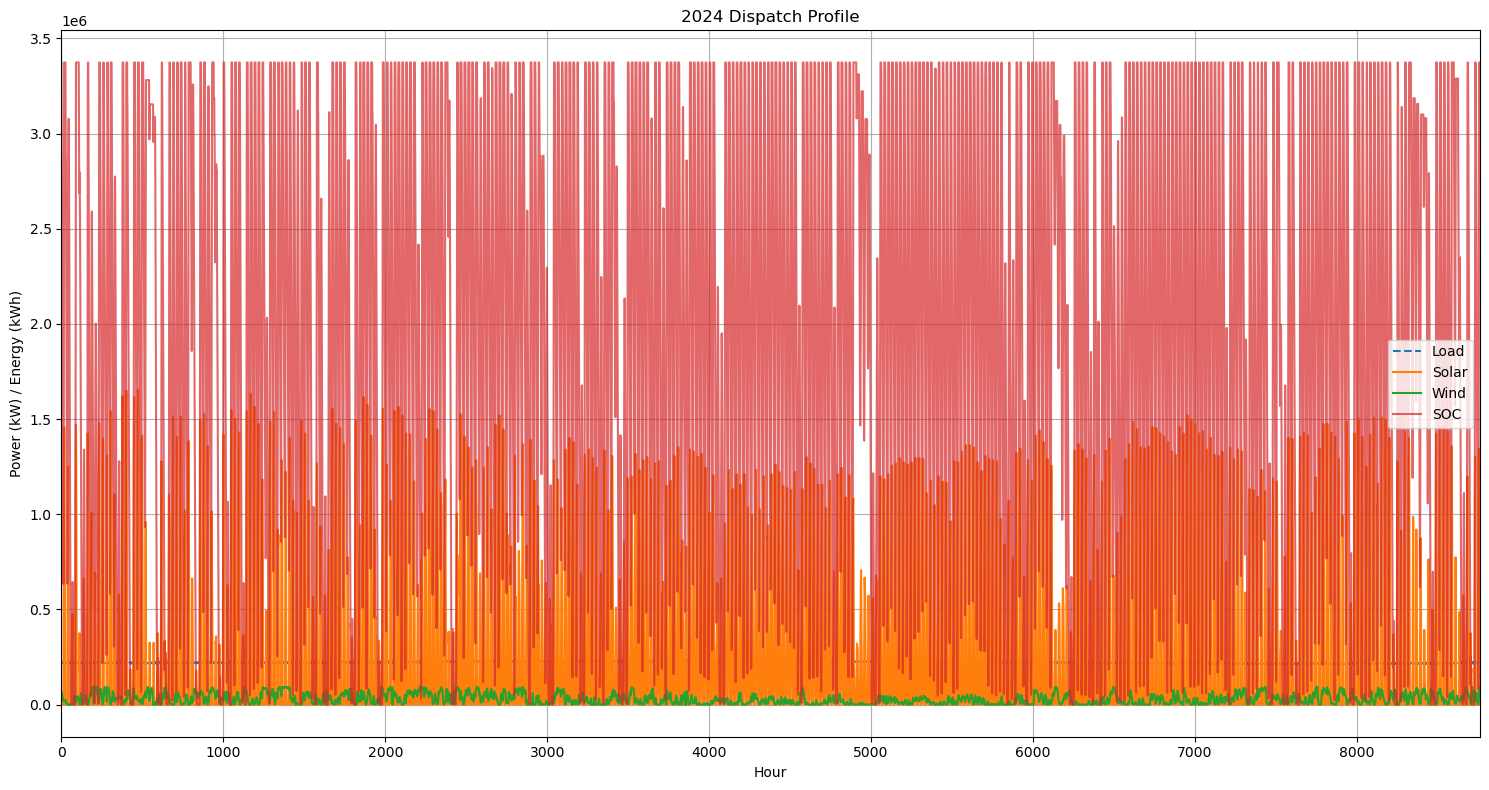

Saved dispatch data to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\dispatch_data_2024.csv
Saved hourly dispatch table to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\hourly_dispatch_2024.csv
Saved battery cycles to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\cycles_2024.csv
Saved dispatch plot to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\dispatch_profile_2024.png
Saved dispatch data to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\dispatch_data_2023.csv
Saved hourly dispatch table to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\hourly_dispatch_2023.csv
Saved battery cycles to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\cycles_2023.csv
Saved dispatch plot to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\dispatch_profile_2023.png
Saved dispatch data to dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment\dispatch_data_2022.csv
Saved hourly dispatch table to dispatch_outputs_solar-wind_dc_92metL

In [7]:
# Clear all user-defined variables
for name in dir():
    if not name.startswith('_'):
        del globals()[name]

import gc
gc.collect()

import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import os

# === CONFIGURE ===
hours = 8760
base_power_csv = 'Desktop/base_power_profile.csv'
solar_csv_2024 = 'Desktop/Solar/2000s/ninja_pv_35.1460_-90.0518_uncorrected (0).csv'
wind_csv_2024 = 'Desktop/Wind/2000s/ninja_wind_35.1460_-90.0518_uncorrected (0).csv'
battery_efficiency = 0.89
dc_series_efficiency = 0.97 * 0.93
life_project = 15
output_dir = "dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment"  # Directory to save plots and CSVs

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === Load and Preprocess 2024 Data ===
try:
    df_base = pd.read_csv(base_power_csv)
    base_power = df_base['Power_W'].to_numpy()
except FileNotFoundError:
    print("Error: base_power_profile.csv not found.")
    exit(1)

# PUE profile
quarter_midpoints = np.linspace(0, hours, 5)
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]
hourly_pue = make_interp_spline(quarter_midpoints, pue_targets, k=3)(np.arange(hours))
dc_ac_conversion_efficiency = 0.975
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)

# 2024 Solar and wind resources
df_solar = pd.read_csv(solar_csv_2024, skiprows=3)
df_wind = pd.read_csv(wind_csv_2024, skiprows=3)
solar_vector = df_solar['electricity']
wind_vector = df_wind['electricity']
solar_resource_2024 = solar_vector[:hours]
wind_resource_2024 = wind_vector[:hours]

# === Optimization Parameters ===
inverter_capacity = (750 / 1000) * 200000 * 1.405 * (0.15 / dc_ac_conversion_efficiency)
cost_solar = 67.6 * 1.1 * 1.25
cost_wind = 5113800
cost_battery = 358
cost_inverter = 165 * 1.1 * 1.0795

om_solar = 7.965
om_wind = 93750
om_battery = 8.52
om_inverter = cost_inverter * 0.05

life_solar = 25
life_wind = 20
life_battery = 10
life_inverter = 10

unmet_load_penalty = 0
total_demand = sum(load_profile)
allowed_unmet = 0.08 * total_demand

inf = 0.023
dis = 0.045
timval = (1 + inf) / (1 + dis)

required_uptime = 0.99671
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5


# === Optimization Function ===
def run_linear_milp_optimization_gurobipy(load_profile, solar_resource, wind_resource,
                                         cost_solar, cost_wind, cost_battery,
                                         unmet_load_penalty, battery_efficiency,
                                         Ns_min, Nw_min, Nb_min):
    try:
        model = gp.Model("EnergySystem")
        
        # Variables
        solar_capacity = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="solar_capacity")
        wind_capacity = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="wind_capacity")
        battery_capacity = model.addVar(lb=1000, vtype=GRB.CONTINUOUS, name="battery_capacity")
        battery_charge = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_charge")
        battery_discharge = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_discharge")
        battery_soc = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="battery_soc")
        unmet_load = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="unmet_load")
        curtailment = model.addVars(hours, lb=0, vtype=GRB.CONTINUOUS, name="curtailment")

        # NPC Calculations
        discount_factor = (1 - (timval)**life_project) / (1 - timval)
        solar_capex = cost_solar * solar_capacity * Ns_min
        wind_capex = cost_wind * wind_capacity * Nw_min
        battery_capex = cost_battery * battery_capacity * Nb_min
        inverter_capex = cost_inverter * inverter_capacity * Ni_min

        solar_opex = om_solar * solar_capacity * timval * discount_factor
        wind_opex = om_wind * wind_capacity * timval * discount_factor
        battery_opex = om_battery * battery_capacity * timval * discount_factor
        inverter_opex = om_inverter * inverter_capacity * timval * discount_factor

        solar_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="solar_replacement")
        wind_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="wind_replacement")
        inverter_replacement = model.addVar(vtype=GRB.CONTINUOUS, name="inverter_replacement")

        if life_solar >= life_project:
            model.addConstr(solar_replacement == 0)
        else:
            model.addConstr(solar_replacement == (solar_capex * (1 + inf)**life_solar) / ((1 + dis)**life_solar))

        if life_wind >= life_project:
            model.addConstr(wind_replacement == 0)
        else:
            model.addConstr(wind_replacement == (wind_capex * (1 + inf)**life_wind) / ((1 + dis)**life_wind))

        if life_inverter >= life_project:
            model.addConstr(inverter_replacement == 0)
        else:
            model.addConstr(inverter_replacement == (inverter_capex * (1 + inf)**life_inverter) / ((1 + dis)**life_inverter))

        solar_salvage = solar_capex * (life_solar - (life_project % life_solar)) / life_solar * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        wind_salvage = wind_capex * (life_wind - (life_project % life_wind)) / life_wind * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        battery_salvage = battery_capex * (life_battery - (life_project % life_battery)) / life_battery * ((1 + inf)**life_project) / ((1 + dis)**life_project)
        inverter_salvage = inverter_capex * (life_inverter - (life_project % life_inverter)) / life_inverter * ((1 + inf)**life_project) / ((1 + dis)**life_project)

        solar_npc = solar_capex + solar_replacement - solar_salvage + solar_opex
        wind_npc = wind_capex + wind_replacement - wind_salvage + wind_opex
        battery_npc = battery_capex - battery_salvage + battery_opex
        inverter_npc = inverter_capex + inverter_replacement - inverter_salvage + inverter_opex

        # Objective
        total_cost = (
            solar_npc +
            wind_npc +
            battery_npc +
            inverter_npc +
            unmet_load_penalty * gp.quicksum(unmet_load[t] for t in range(hours))
        )
        model.setObjective(total_cost, GRB.MINIMIZE)

        # Constraints
        model.addConstr(battery_soc[0] == battery_capacity, name="initial_soc")
        for t in range(hours):
            solar_gen = solar_resource[t] * solar_capacity * dc_series_efficiency
            wind_gen = wind_resource[t] * wind_capacity * dc_series_efficiency
            net_gen = solar_gen + wind_gen
            model.addConstr(battery_soc[t] <= battery_capacity, name=f"soc_upper_{t}")
            model.addConstr(battery_charge[t] <= battery_capacity, name=f"charge_upper_{t}")
            model.addConstr(battery_discharge[t] <= battery_capacity, name=f"discharge_upper_{t}")
            model.addConstr(battery_discharge[t] <= battery_soc[t], name=f"discharge_limit_{t}")
            model.addConstr(
                net_gen + battery_discharge[t] * dc_series_efficiency -
                battery_charge[t] / battery_efficiency - curtailment[t] -
                load_profile[t] + unmet_load[t] == 0,
                name=f"energy_balance_{t}"
            )
            model.addConstr(gp.quicksum(unmet_load[t] for t in range(hours)) <= allowed_unmet, name="unmet_load_limit")
            model.addConstr(battery_charge[t] * battery_discharge[t] <= 0, name=f"no_simul_charge_discharge_{t}")
            if t > 0:
                model.addConstr(
                    battery_soc[t] == battery_soc[t-1] +
                    battery_charge[t] -
                    battery_discharge[t] / battery_efficiency,
                    name=f"soc_update_{t}"
                )
        model.addConstr(battery_soc[hours-1] >= 0 * battery_capacity, name="min_final_soc")

        model.setParam("TimeLimit", 1000)
        model.setParam("MIPGap", 0.01)
        model.setParam("NumericFocus", 3)
        model.setParam("OutputFlag", 1)
        model.setParam("MIPFocus", 1)

        model.optimize()

        if model.status == GRB.OPTIMAL:
            print("Optimal Solution Found!")
            print(f"Solar Capacity: {solar_capacity.x:.2f} PV")
            print(f"Wind Capacity: {wind_capacity.x:.2f} HAWT")
            print(f"Battery Capacity: {battery_capacity.x:.2f} kWh")
            return {
                "solar": solar_capacity.x,
                "wind": wind_capacity.x,
                "battery": battery_capacity.x,
                "cost": model.objVal,
                "solar_capex": solar_capex.getValue(),
                "solar_opex": solar_opex.getValue(),
                "solar_replacement": solar_replacement.x,
                "solar_salvage": solar_salvage.getValue(),
                "wind_capex": wind_capex.getValue(),
                "wind_opex": wind_opex.getValue(),
                "wind_replacement": wind_replacement.x,
                "wind_salvage": wind_salvage.getValue(),
                "battery_capex": battery_capex.getValue(),
                "battery_opex": battery_opex.getValue(),
                "battery_salvage": battery_salvage.getValue(),
                "inverter_capex": inverter_capex,
                "inverter_opex": inverter_opex,
                "inverter_replacement": inverter_replacement.x,
                "inverter_salvage": inverter_salvage
            }
        else:
            print(f"Optimization Failed. Status: {model.status}")
            if model.status == GRB.INFEASIBLE:
                model.computeIIS()
                model.write("conflict.ilp")
                print("IIS written to conflict.ilp")
            return {"status": model.status}

    except gp.GurobiError as e:
        print(f"Gurobi Error: {e}")
        return {"status": "error"}
    except Exception as e:
        print(f"Error: {e}")
        return {"status": "error"}

# === Degradation Function ===
def calculate_rainflow_degradation_verbose(soc_series, capacity, A=0.000144, beta=1.79, dod_threshold=0):
    soc_series = np.array(soc_series)
    total_degradation = 0.0
    cycle_info = []
    peak = soc_series[0]
    valley = peak
    direction = None
    peak_hour = 0
    valley_hour = 0

    for i in range(1, len(soc_series)):
        if soc_series[i] > soc_series[i - 1]:
            if direction == 'down':
                dod = (peak - valley) / capacity if capacity > 0 else 0
                if dod >= dod_threshold:
                    degradation = A * (dod ** beta)
                    total_degradation += degradation
                    cycle_info.append({
                        "type": "discharge",
                        "peak_hour": peak_hour,
                        "valley_hour": valley_hour,
                        "DoD": round(dod, 4),
                        "degradation": round(degradation, 6)
                    })
                peak = soc_series[i]
                peak_hour = i
                direction = 'up'
            else:
                peak = max(peak, soc_series[i])
                if peak == soc_series[i]:
                    peak_hour = i
                direction = 'up'
        elif soc_series[i] < soc_series[i - 1]:
            if direction == 'up':
                valley = soc_series[i]
                valley_hour = i
                direction = 'down'
            else:
                valley = min(valley, soc_series[i])
                if valley == soc_series[i]:
                    valley_hour = i
                direction = 'down'

    return cycle_info, total_degradation

# === Function to Calculate Battery Replacement Cost ===
def calculate_battery_replacement_cost(battery_capex, degradation, inf, dis, life_battery):
    if degradation < 1:
        replacement_yearly = (battery_capex / (1 - degradation)) - battery_capex
        print(f"${replacement_yearly:.2f} is the replacement cost each year for degradation")
    else:
        replacement_yearly = 0

    battery_replacement_npc = 0
    for t in range(1, life_project + 1):
        battery_replacement_npc += replacement_yearly * ((1 + inf) ** t) / ((1 + dis) ** t)

    return battery_replacement_npc

# === Dispatch Simulation ===
def simulate_dispatch_fixed_capacities(load_profile, solar_resource, wind_resource,
                                      fixed_solar, fixed_wind, fixed_battery,
                                      battery_efficiency=0.89, initial_soc=0):
    hours = len(load_profile)
    model = gp.Model("fixed_dispatch")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 300

    battery_charge = model.addVars(hours, lb=0, name="charge")
    battery_discharge = model.addVars(hours, lb=0, name="discharge")
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery, name="soc")
    unmet_load = model.addVars(hours, lb=0, name="unmet")
    curtailment = model.addVars(hours, lb=0, name="curtailment")

    model.addConstr(battery_soc[0] == initial_soc)

    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_series_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_series_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(battery_soc[t] <= fixed_battery)
        model.addConstr(battery_discharge[t] <= battery_soc[t])

        if t > 0:
            model.addConstr(
                battery_soc[t] == battery_soc[t - 1] +
                battery_charge[t] -
                battery_discharge[t] / battery_efficiency
            )

        model.addConstr(
            net_gen + battery_discharge[t] * dc_series_efficiency -
            battery_charge[t] / battery_efficiency - curtailment[t] -
            load_profile[t] + unmet_load[t] == 0
        )

    model.setObjective(gp.quicksum(unmet_load[t] for t in range(hours)), GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        battery_soc_vals = np.array([battery_soc[t].X for t in range(hours)])
        battery_charge_vals = np.array([battery_charge[t].X for t in range(hours)])
        battery_discharge_vals = np.array([battery_discharge[t].X for t in range(hours)])
        cycles, degradation = calculate_rainflow_degradation_verbose(battery_soc_vals, fixed_battery)

        return {
            "total_unmet": sum(unmet_load[t].X for t in range(hours)),
            "unmet_hours": [t for t in range(hours) if unmet_load[t].X > 1e-3],
            "unmet_profile": np.array([unmet_load[t].X for t in range(hours)]),
            "battery_soc": battery_soc_vals,
            "battery_charge": battery_charge_vals,
            "battery_discharge": battery_discharge_vals,
            "curtailment": np.array([curtailment[t].X for t in range(hours)]),
            "cycles": cycles,
            "degradation": degradation
        }
    else:
        return None

# === Function to Load Yearly Resources ===
def load_yearly_resources(year):
    try:
        if year >= 2000:
            idx = 2024 - year
            solar_csv = f'Desktop/Solar/2000s/ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv'
            wind_csv = f'Desktop/Wind/2000s/ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv'
        else:
            idx = year - 1900
            solar_csv = f'Desktop/Solar/1900s/ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv'
            wind_csv = f'Desktop/Wind/1900s/ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv'

        df_solar = pd.read_csv(solar_csv, skiprows=3)
        df_wind = pd.read_csv(wind_csv, skiprows=3)
        solar_vector = df_solar['electricity']
        wind_vector = df_wind['electricity']
        return solar_vector[:hours], wind_vector[:hours]
    except FileNotFoundError:
        print(f"Error: Resource files for year {year} not found.")
        return None, None

# === Function to Save Plot, CSVs, and Dispatch Text ===
def save_dispatch_output(year, dispatch_result, load_profile, solar_resource, wind_resource, fixed_solar, fixed_wind):
    df_dispatch = pd.DataFrame({
        "Hour": np.arange(hours),
        "Load (kW)": load_profile,
        "Solar (kW)": solar_resource * fixed_solar,
        "Wind (kW)": wind_resource * fixed_wind,
        "SOC (kWh)": dispatch_result["battery_soc"],
        "Charge (kW)": dispatch_result["battery_charge"],
        "Discharge (kW)": dispatch_result["battery_discharge"],
        "Unmet (kW)": dispatch_result["unmet_profile"],
        "Curtailment (kW)": dispatch_result["curtailment"]
    })

    # Save dispatch data CSV
    csv_path = os.path.join(output_dir, f"dispatch_data_{year}.csv")
    df_dispatch.to_csv(csv_path, index=False)
    print(f"Saved dispatch data to {csv_path}")

    # Save hourly dispatch table CSV
    dispatch_table_path = os.path.join(output_dir, f"hourly_dispatch_{year}.csv")
    df_dispatch.to_csv(dispatch_table_path, index=False)
    print(f"Saved hourly dispatch table to {dispatch_table_path}")

    # Save cycles CSV
    df_cycles = pd.DataFrame(dispatch_result["cycles"])
    cycles_path = os.path.join(output_dir, f"cycles_{year}.csv")
    df_cycles.to_csv(cycles_path, index=False)
    print(f"Saved battery cycles to {cycles_path}")

    # Save Plot
    plt.figure(figsize=(15, 8))
    plt.plot(df_dispatch["Hour"], df_dispatch["Load (kW)"], label="Load", linestyle='--')
    plt.plot(df_dispatch["Hour"], df_dispatch["Solar (kW)"], label="Solar")
    plt.plot(df_dispatch["Hour"], df_dispatch["Wind (kW)"], label="Wind")
    plt.plot(df_dispatch["Hour"], df_dispatch["SOC (kWh)"], label="SOC", alpha=0.7)
    plt.xlim(0, 8760)
    plt.legend()
    plt.grid(True)
    plt.title(f"Dispatch Profile for {year}")
    plt.xlabel("Hour")
    plt.ylabel("Power (kW) / Energy (kWh)")
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f"dispatch_profile_{year}.png")
    plt.savefig(plot_path)
    plt.close()
    print(f"Saved dispatch plot to {plot_path}")

    return df_dispatch, df_cycles

# === Run Optimization for 2024 ===
opt_results = run_linear_milp_optimization_gurobipy(
    load_profile, solar_resource_2024, wind_resource_2024,
    cost_solar, cost_wind, cost_battery,
    unmet_load_penalty, battery_efficiency,
    Ns_min, Nw_min, Nb_min
)

# === Process Results ===
if isinstance(opt_results, dict) and "status" not in opt_results:
    # Run dispatch simulation for 2024 (full output)
    dispatch_result = simulate_dispatch_fixed_capacities(
        load_profile=load_profile,
        solar_resource=solar_resource_2024,
        wind_resource=wind_resource_2024,
        fixed_solar=opt_results["solar"],
        fixed_wind=opt_results["wind"],
        fixed_battery=opt_results["battery"],
        initial_soc=opt_results["battery"]
    )

    if dispatch_result:
        # Calculate curtailment, generation, and percentage
        total_curtailed = np.sum(dispatch_result["curtailment"])
        solar_gen = solar_resource_2024 * opt_results["solar"] 
        wind_gen = wind_resource_2024 * opt_results["wind"] 
        total_generated = np.sum(solar_gen + wind_gen)
        total_power_consumed = total_generated-total_curtailed
        utilization_percentage = (total_power_consumed / total_generated * 100) if total_generated > 0 else 0

        # Print results
        print("\n=== 2024 Curtailment and Generation Metrics ===")
        print(f"Total Energy Curtailed: {total_curtailed:.2f} kWh")
        print(f"Total Energy Generated: {total_generated:.2f} kWh")
        print(f"Total Energy Used (along with efficiency losses): {total_power_consumed:.2f} kWh")
        print(f"Utilization Percentage: {utilization_percentage:.2f}%")
        
        # Calculate redundant capacities and costs
        solar_initial_capacity = opt_results["solar"]
        wind_initial_capacity = opt_results["wind"]
        battery_initial_capacity = opt_results["battery"]
        inverter_initial_capacity = inverter_capacity

        solar_initial_cost = cost_solar * solar_initial_capacity
        wind_initial_cost = cost_wind * wind_initial_capacity
        battery_initial_cost = cost_battery * battery_initial_capacity
        inverter_initial_cost = cost_inverter * inverter_initial_capacity

        solar_redundant_capacity = (Ns_min - 1) * opt_results["solar"]
        wind_redundant_capacity = (Nw_min - 1) * opt_results["wind"]
        battery_redundant_capacity = (Nb_min - 1) * opt_results["battery"]
        inverter_redundant_capacity = inverter_capacity * (Ni_min-1)

        solar_redundant_cost = cost_solar * solar_redundant_capacity
        wind_redundant_cost = cost_wind * wind_redundant_capacity
        battery_redundant_cost = cost_battery * battery_redundant_capacity
        inverter_redundant_cost = cost_inverter * inverter_redundant_capacity
        
        # Calculate battery replacement cost
        yearly_degradation = dispatch_result["degradation"]
        battery_replacement = calculate_battery_replacement_cost(
            battery_capex=opt_results["battery_capex"],
            degradation=yearly_degradation,
            inf=inf,
            dis=dis,
            life_battery=life_battery
        )

        # Update total NPC
        total_npc = opt_results["cost"] + battery_replacement

        # Display initial capacities and costs
        print("\nRedundant Capacities and Costs:")
        print(f"Solar Initial Capacity: {solar_initial_capacity:.2f} PV")
        print(f"Solar Initial Cost:    ${solar_initial_cost:.2f}")
        print(f"Wind Initial Capacity: {wind_initial_capacity:.2f} HAWT")
        print(f"Wind Initial Cost:     ${wind_initial_cost:.2f}")
        print(f"Battery Initial Capacity: {battery_initial_capacity:.2f} kWh")
        print(f"Battery Initial Cost:  ${battery_initial_cost:.2f}")
        print(f"Inverter Initial Capacity: {inverter_initial_capacity:.2f} kW")
        print(f"Inverter Initial Cost:  ${inverter_initial_cost:.2f}")

        # Display redundant capacities and costs
        print("\nRedundant Capacities and Costs:")
        print(f"Solar Redundant Capacity: {solar_redundant_capacity:.2f} PV")
        print(f"Solar Redundant Cost:    ${solar_redundant_cost:.2f}")
        print(f"Wind Redundant Capacity: {wind_redundant_capacity:.2f} HAWT")
        print(f"Wind Redundant Cost:     ${wind_redundant_cost:.2f}")
        print(f"Battery Redundant Capacity: {battery_redundant_capacity:.2f} kWh")
        print(f"Battery Redundant Cost:  ${battery_redundant_cost:.2f}")
        print(f"Inverter Redundant Capacity: {inverter_redundant_capacity:.2f} kW")
        print(f"Inverter Redundant Cost:  ${inverter_redundant_cost:.2f}")

        # Display cost breakdown
        print("\nCost Breakdown:")
        print(f"Solar CAPEX:        ${opt_results['solar_capex']:.2f}")
        print(f"Solar OPEX:         ${opt_results['solar_opex']:.2f}")
        print(f"Solar Replacement:  ${opt_results['solar_replacement']:.2f}")
        print(f"Solar Salvage:     -${opt_results['solar_salvage']:.2f}")
        print(f"Wind CAPEX:         ${opt_results['wind_capex']:.2f}")
        print(f"Wind OPEX:          ${opt_results['wind_opex']:.2f}")
        print(f"Wind Replacement:   ${opt_results['wind_replacement']:.2f}")
        print(f"Wind Salvage:      -${opt_results['wind_salvage']:.2f}")
        print(f"Battery CAPEX:      ${opt_results['battery_capex']:.2f}")
        print(f"Battery OPEX:       ${opt_results['battery_opex']:.2f}")
        print(f"Battery Replacement:${battery_replacement:.2f}")
        print(f"Battery Salvage:   -${opt_results['battery_salvage']:.2f}")
        print(f"Inverter CAPEX:     ${opt_results['inverter_capex']:.2f}")
        print(f"Inverter OPEX:      ${opt_results['inverter_opex']:.2f}")
        print(f"Inverter Replacement:${opt_results['inverter_replacement']:.2f}")
        print(f"Inverter Salvage:   -${opt_results['inverter_salvage']:.2f}")
        print(f"Total NPC:          ${total_npc:.2f}")

        print("\n=== 2024 Results ===")
        print(f"Total Unmet Load: {dispatch_result['total_unmet']:.2f} kWh")
        print(f"Hours with Unmet Load: {dispatch_result['unmet_hours']}")
        print("\nDetected Battery Cycles:")
        df_cycles = pd.DataFrame(dispatch_result["cycles"])
        print(df_cycles.to_string(index=False))
        print(f"\nTotal Estimated Degradation: {dispatch_result['degradation']:.6f}")

        df_dispatch, df_cycles = save_dispatch_output(
            year=2024,
            dispatch_result=dispatch_result,
            load_profile=load_profile,
            solar_resource=solar_resource_2024,
            wind_resource=wind_resource_2024,
            fixed_solar=opt_results["solar"],
            fixed_wind=opt_results["wind"]
        )

        # Display plot for 2024
        plt.figure(figsize=(15, 8))
        plt.plot(df_dispatch["Hour"], df_dispatch["Load (kW)"], label="Load", linestyle='--')
        plt.plot(df_dispatch["Hour"], df_dispatch["Solar (kW)"], label="Solar")
        plt.plot(df_dispatch["Hour"], df_dispatch["Wind (kW)"], label="Wind")
        plt.plot(df_dispatch["Hour"], df_dispatch["SOC (kWh)"], label="SOC", alpha=0.7)
        plt.xlim(0, 8760)
        plt.legend()
        plt.grid(True)
        plt.title("2024 Dispatch Profile")
        plt.xlabel("Hour")
        plt.ylabel("Power (kW) / Energy (kWh)")
        plt.tight_layout()
        plt.show()

        # === Evaluate Unmet Load for All Years ===
        unmet_loads = {}
        for year in range(2024, 1979, -1):
            solar_resource, wind_resource = load_yearly_resources(year)
            if solar_resource is None or wind_resource is None:
                unmet_loads[year] = None
                continue

            dispatch_result = simulate_dispatch_fixed_capacities(
                load_profile=load_profile,
                solar_resource=solar_resource,
                wind_resource=wind_resource,
                fixed_solar=opt_results["solar"],
                fixed_wind=opt_results["wind"],
                fixed_battery=opt_results["battery"],
                initial_soc=opt_results["battery"]
            )

            if dispatch_result:
                unmet_loads[year] = dispatch_result["total_unmet"]
                save_dispatch_output(
                    year=year,
                    dispatch_result=dispatch_result,
                    load_profile=load_profile,
                    solar_resource=solar_resource,
                    wind_resource=wind_resource,
                    fixed_solar=opt_results["solar"],
                    fixed_wind=opt_results["wind"]
                )
            else:
                unmet_loads[year] = None

        # === Display Unmet Load Results ===
        print("\n=== Unmet Load Across Years ===")
        valid_unmet_loads = []
        for year in range(2024, 1979, -1):
            if unmet_loads[year] is not None:
                print(f"Year {year}: Unmet Load = {unmet_loads[year]:.2f} kWh")
                valid_unmet_loads.append(unmet_loads[year])
            else:
                print(f"Year {year}: Unmet Load = Failed (missing data or optimization error)")

        if valid_unmet_loads:
            avg_unmet = np.mean(valid_unmet_loads)
            print(f"\nAverage Unmet Load (1979-2024): {avg_unmet:.2f} kWh")
            print(f"Min Unmet Load: {min(valid_unmet_loads):.2f} kWh (Year {min((year for year, val in unmet_loads.items() if val == min(valid_unmet_loads)), default='N/A')})")
            print(f"Max Unmet Load: {max(valid_unmet_loads):.2f} kWh (Year {max((year for year, val in unmet_loads.items() if val == max(valid_unmet_loads)), default='N/A')})")
        else:
            print("\nNo valid unmet load data available.")

        # === Save Capacity, Cost, and Utilization Metrics for All Years ===
        print("Starting capacity, cost, and utilization metrics collection...")
        results_by_year = []
        for year in range(2024, 1979, -1):
            print(f"Processing year {year} for capacity, cost, and utilization metrics...")
            solar_resource, wind_resource = load_yearly_resources(year)
            if solar_resource is None or wind_resource is None:
                print(f"Year {year}: Skipping due to missing resource data.")
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": None,
                    "Wind_Capacity_HAWT": None,
                    "Battery_Capacity_kWh": None,
                    "Inverter_Capacity_kW": None,
                    "Solar_CAPEX": None,
                    "Solar_OPEX": None,
                    "Solar_Replacement": None,
                    "Solar_Salvage": None,
                    "Wind_CAPEX": None,
                    "Wind_OPEX": None,
                    "Wind_Replacement": None,
                    "Wind_Salvage": None,
                    "Battery_CAPEX": None,
                    "Battery_OPEX": None,
                    "Battery_Replacement": None,
                    "Battery_Salvage": None,
                    "Inverter_CAPEX": None,
                    "Inverter_OPEX": None,
                    "Inverter_Replacement": None,
                    "Inverter_Salvage": None,
                    "Total_NPC": None,
                    "Utilization_Percentage": None,
                    "Total_Curtailed_kWh": None,
                    "Total_Generated_kWh": None,
                    "Total_Power_Consumed_kWh": None,
                    "Total_Unmet_kWh": None
                })
                continue

            dispatch_result = simulate_dispatch_fixed_capacities(
                load_profile=load_profile,
                solar_resource=solar_resource,
                wind_resource=wind_resource,
                fixed_solar=opt_results["solar"],
                fixed_wind=opt_results["wind"],
                fixed_battery=opt_results["battery"],
                initial_soc=opt_results["battery"]
            )

            if dispatch_result:
                print(f"Year {year}: Dispatch simulation successful, calculating metrics...")
                # Calculate utilization metrics
                total_curtailed = np.sum(dispatch_result["curtailment"])
                solar_gen = solar_resource * opt_results["solar"]
                wind_gen = wind_resource * opt_results["wind"]
                total_generated = np.sum(solar_gen + wind_gen)
                total_power_consumed = total_generated - total_curtailed
                utilization_percentage = (total_power_consumed / total_generated * 100) if total_generated > 0 else 0

                # Calculate battery replacement cost
                yearly_degradation = dispatch_result["degradation"]
                battery_replacement = calculate_battery_replacement_cost(
                    battery_capex=opt_results["battery_capex"],
                    degradation=yearly_degradation,
                    inf=inf,
                    dis=dis,
                    life_battery=life_battery
                )

                # Calculate total NPC
                total_npc = (
                    opt_results["solar_capex"] +
                    opt_results["solar_opex"] +
                    opt_results["solar_replacement"] -
                    opt_results["solar_salvage"] +
                    opt_results["wind_capex"] +
                    opt_results["wind_opex"] +
                    opt_results["wind_replacement"] -
                    opt_results["wind_salvage"] +
                    opt_results["battery_capex"] +
                    opt_results["battery_opex"] +
                    battery_replacement -
                    opt_results["battery_salvage"] +
                    opt_results["inverter_capex"] +
                    opt_results["inverter_opex"] +
                    opt_results["inverter_replacement"] -
                    opt_results["inverter_salvage"]
                )

                # Store results
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": opt_results["solar"],
                    "Wind_Capacity_HAWT": opt_results["wind"],
                    "Battery_Capacity_kWh": opt_results["battery"],
                    "Inverter_Capacity_kW": inverter_capacity,
                    "Solar_CAPEX": opt_results["solar_capex"],
                    "Solar_OPEX": opt_results["solar_opex"],
                    "Solar_Replacement": opt_results["solar_replacement"],
                    "Solar_Salvage": opt_results["solar_salvage"],
                    "Wind_CAPEX": opt_results["wind_capex"],
                    "Wind_OPEX": opt_results["wind_opex"],
                    "Wind_Replacement": opt_results["wind_replacement"],
                    "Wind_Salvage": opt_results["wind_salvage"],
                    "Battery_CAPEX": opt_results["battery_capex"],
                    "Battery_OPEX": opt_results["battery_opex"],
                    "Battery_Replacement": battery_replacement,
                    "Battery_Salvage": opt_results["battery_salvage"],
                    "Inverter_CAPEX": opt_results["inverter_capex"],
                    "Inverter_OPEX": opt_results["inverter_opex"],
                    "Inverter_Replacement": opt_results["inverter_replacement"],
                    "Inverter_Salvage": opt_results["inverter_salvage"],
                    "Total_NPC": total_npc,
                    "Utilization_Percentage": utilization_percentage,
                    "Total_Curtailed_kWh": total_curtailed,
                    "Total_Generated_kWh": total_generated,
                    "Total_Power_Consumed_kWh": total_power_consumed,
                    "Total_Unmet_kWh": dispatch_result["total_unmet"]
                })
                print(f"Year {year}: Metrics added - Utilization: {utilization_percentage:.2f}%, NPC: {total_npc:.2f}, Unmet: {dispatch_result['total_unmet']:.2f} kWh")
            else:
                print(f"Year {year}: Metrics save failed due to dispatch simulation error.")
                results_by_year.append({
                    "Year": year,
                    "Solar_Capacity_PV": None,
                    "Wind_Capacity_HAWT": None,
                    "Battery_Capacity_kWh": None,
                    "Inverter_Capacity_kW": None,
                    "Solar_CAPEX": None,
                    "Solar_OPEX": None,
                    "Solar_Replacement": None,
                    "Solar_Salvage": None,
                    "Wind_CAPEX": None,
                    "Wind_OPEX": None,
                    "Wind_Replacement": None,
                    "Wind_Salvage": None,
                    "Battery_CAPEX": None,
                    "Battery_OPEX": None,
                    "Battery_Replacement": None,
                    "Battery_Salvage": None,
                    "Inverter_CAPEX": None,
                    "Inverter_OPEX": None,
                    "Inverter_Replacement": None,
                    "Inverter_Salvage": None,
                    "Total_NPC": None,
                    "Utilization_Percentage": None,
                    "Total_Curtailed_kWh": None,
                    "Total_Generated_kWh": None,
                    "Total_Power_Consumed_kWh": None,
                    "Total_Unmet_kWh": None
                })

        # Save results to CSV
        try:
            df_results = pd.DataFrame(results_by_year)
            csv_path = os.path.join(output_dir, "capacity_and_costs_by_year.csv")
            df_results.to_csv(csv_path, index=False)
            print(f"Saved capacity, cost, and utilization metrics to {csv_path}")
            print(f"CSV file location: {os.path.abspath(csv_path)}")
        except Exception as e:
            print(f"Error saving CSV: {e}")

        # === Plot NPC Variation Across Years ===
        print("Starting NPC variation plotting...")
        try:
            valid_npc_data = df_results[df_results["Total_NPC"].notna()][["Year", "Total_NPC"]]
            if valid_npc_data.empty:
                print("Error: No valid NPC data found for plotting.")
            else:
                plt.figure(figsize=(15, 8))
                plt.plot(valid_npc_data["Year"], valid_npc_data["Total_NPC"], marker='o', linestyle='-', color='b')
                plt.title("NPC Variation Across Years (1979-2024)")
                plt.xlabel("Year")
                plt.ylabel("Total NPC ($)")
                plt.grid(True)
                plt.gca().invert_xaxis()  # Reverse x-axis to show 2024 to 1979
                plt.tight_layout()
                plot_path = os.path.join(output_dir, "npc_variation_by_year.png")
                plt.savefig(plot_path)
                plt.close()
                print(f"Saved NPC variation plot to {plot_path}")
                print(f"Plot file location: {os.path.abspath(plot_path)}")
        except Exception as e:
            print(f"Error plotting NPC variation: {e}")

    else:
        print("Dispatch simulation for 2024 failed.")
else:
    print("Optimization for 2024 failed.")

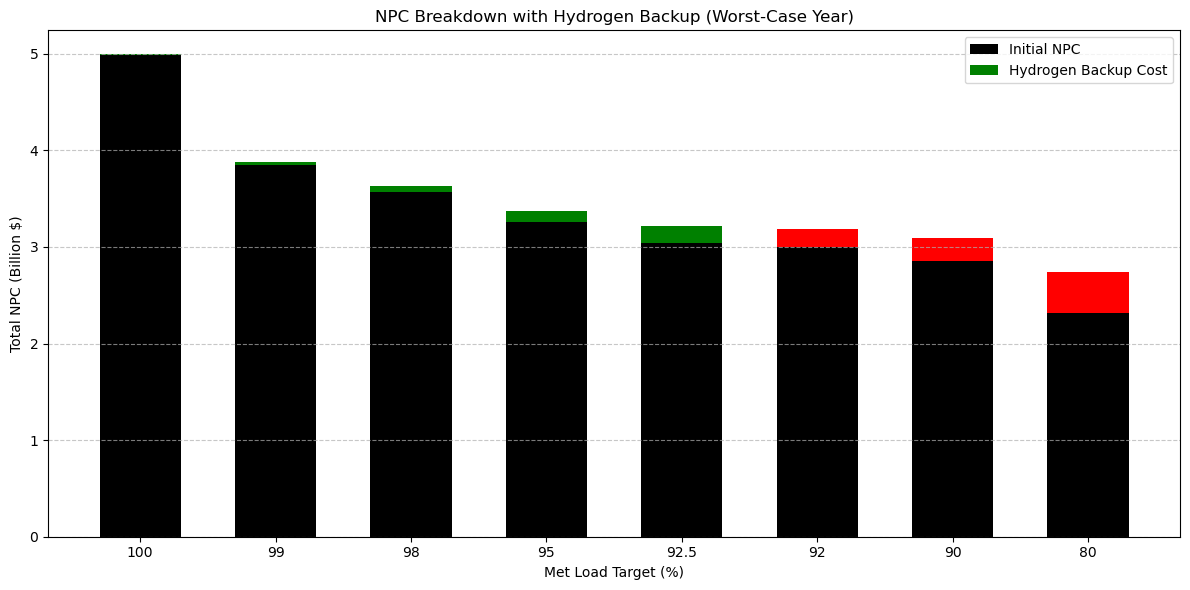

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_efficiency = 0.40
hydrogen_energy_density = 40  # kWh/kg
electrolyzer_cost_per_kw = 1500
fuel_cell_cost_per_kw = 1000
hydrogen_storage_cost_per_kg = 2
hours_per_year = 8760
electrolyzer_utilization_hours = 8760
fuel_cell_peak_margin = 2.0

# === Folder paths ===
folders = {
    "100": r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    "99":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    "98":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    "95":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    "92.5":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment",
    "92":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment",
    "90":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    "80":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}

# === Storage ===
metloads = []
initial_npcs = []
hydrogen_costs = []
hydrogen_sufficient_flags = []

# === Loop through each folder
for met, folder in folders.items():
    csv_path = os.path.join(folder, "capacity_and_costs_by_year.csv")
    if not os.path.exists(csv_path):
        continue

    df = pd.read_csv(csv_path)
    worst_row = df.loc[df['Total_Unmet_kWh'].idxmax()]
    unmet_kwh = worst_row['Total_Unmet_kWh']
    curtailed_kwh = worst_row['Total_Curtailed_kWh']
    base_npc = worst_row['Total_NPC']

    # Hydrogen requirement
    dc_bus_kwh = unmet_kwh / dc_efficiency
    hydrogen_input_kwh = dc_bus_kwh / hydrogen_efficiency
    hydrogen_kg = hydrogen_input_kwh / hydrogen_energy_density

    # Electrolyzer sizing
    electrolyzer_kw = hydrogen_input_kwh / electrolyzer_utilization_hours
    electrolyzer_cost = electrolyzer_kw * electrolyzer_cost_per_kw

    # Fuel cell sizing
    avg_unmet_kw = unmet_kwh / hours_per_year
    fuel_cell_kw = avg_unmet_kw * fuel_cell_peak_margin
    fuel_cell_cost = fuel_cell_kw * fuel_cell_cost_per_kw

    # Hydrogen storage
    storage_cost = hydrogen_kg * hydrogen_storage_cost_per_kg

    # Total hydrogen cost
    hydrogen_cost = electrolyzer_cost + fuel_cell_cost + storage_cost

    # Check if curtailed energy is enough
    hydrogen_sufficient = curtailed_kwh >= hydrogen_input_kwh

    # Store results
    metloads.append(met)
    initial_npcs.append(base_npc / 1e9)
    hydrogen_costs.append(hydrogen_cost / 1e9)
    hydrogen_sufficient_flags.append(hydrogen_sufficient)

# === Plotting
x = np.arange(len(metloads))
bar_width = 0.6
bar_colors = ['green' if flag else 'red' for flag in hydrogen_sufficient_flags]

plt.figure(figsize=(12, 6))
# Initial NPC bars
plt.bar(x, initial_npcs, color='black', width=bar_width, label='Initial NPC')
# Hydrogen cost bars stacked
plt.bar(x, hydrogen_costs, bottom=initial_npcs, color=bar_colors, width=bar_width, label='Hydrogen Backup Cost')

plt.xticks(x, metloads)
plt.xlabel("Met Load Target (%)")
plt.ylabel("Total NPC (Billion $)")
plt.title("NPC Breakdown with Hydrogen Backup (Worst-Case Year)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
import os
import numpy as np
import pandas as pd

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_efficiency = 0.40
hydrogen_energy_density = 40  # kWh/kg
electrolyzer_cost_per_kw = 1500
fuel_cell_cost_per_kw = 1000
hydrogen_storage_cost_per_kg = 2
hours_per_year = 8760
electrolyzer_utilization_hours = 8760
fuel_cell_peak_margin = 2.0

# === Folder paths on your machine ===
folders = {
    "100": r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    "99":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    "98":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    "95":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    "92.5":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment",
    "92":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment",
    "90":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    "80":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}

# === Storage ===
summary_data = []

# === Loop through each folder
for met, folder in folders.items():
    csv_path = os.path.join(folder, "capacity_and_costs_by_year.csv")
    if not os.path.exists(csv_path):
        print(f"Missing file for {met}%: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    worst_row = df.loc[df['Total_Unmet_kWh'].idxmax()]
    unmet_kwh = worst_row['Total_Unmet_kWh']
    curtailed_kwh = worst_row['Total_Curtailed_kWh']
    
    # Hydrogen requirement
    dc_bus_kwh = unmet_kwh / dc_efficiency
    hydrogen_input_kwh = dc_bus_kwh / hydrogen_efficiency
    hydrogen_kg = hydrogen_input_kwh / hydrogen_energy_density

    # Electrolyzer sizing
    electrolyzer_kw = hydrogen_input_kwh / electrolyzer_utilization_hours
    electrolyzer_cost = electrolyzer_kw * electrolyzer_cost_per_kw

    # Fuel cell sizing
    avg_unmet_kw = unmet_kwh / hours_per_year
    fuel_cell_kw = avg_unmet_kw * fuel_cell_peak_margin
    fuel_cell_cost = fuel_cell_kw * fuel_cell_cost_per_kw

    # Hydrogen storage
    storage_cost = hydrogen_kg * hydrogen_storage_cost_per_kg

    # Total hydrogen cost
    hydrogen_cost = electrolyzer_cost + fuel_cell_cost + storage_cost

    # Feasibility
    hydrogen_sufficient = curtailed_kwh >= hydrogen_input_kwh

    # Append to table
    summary_data.append({
        "Met Load Target (%)": met,
        "Unmet Load (kWh)": round(unmet_kwh, 2),
        "Curtailed Energy (kWh)": round(curtailed_kwh, 2),
        "Hydrogen Input Required (kWh)": round(hydrogen_input_kwh, 2),
        "Hydrogen Mass Required (kg)": round(hydrogen_kg, 2),
        "Electrolyzer Cost ($)": round(electrolyzer_cost, 2),
        "Fuel Cell Cost ($)": round(fuel_cell_cost, 2),
        "Storage Cost ($)": round(storage_cost, 2),
        "Total Hydrogen Cost ($)": round(hydrogen_cost, 2),
        "Hydrogen Feasible from Curtailment": hydrogen_sufficient
    })

# Convert to DataFrame and display/save
df_summary = pd.DataFrame(summary_data)
print(df_summary)

# Optional: save as CSV
# df_summary.to_csv("hydrogen_backup_summary.csv", index=False)


  Met Load Target (%)  Unmet Load (kWh)  Curtailed Energy (kWh)  \
0                 100      7.810984e+06            3.303385e+09   
1                  99      4.010495e+07            2.008046e+09   
2                  98      6.252591e+07            1.493402e+09   
3                  95      1.273341e+08            8.516274e+08   
4                92.5      1.971996e+08            6.104108e+08   
5                  92      2.109589e+08            5.660747e+08   
6                  90      2.636444e+08            4.526609e+08   
7                  80      4.782037e+08            2.274079e+08   

   Hydrogen Input Required (kWh)  Hydrogen Mass Required (kg)  \
0                   2.164667e+07                    541166.70   
1                   1.111433e+08                   2778582.63   
2                   1.732788e+08                   4331968.93   
3                   3.528824e+08                   8822059.17   
4                   5.465015e+08                  13662536.32   
5     

  Met Load Target (%)  Unmet Load (kWh)  Curtailed Energy (kWh)  \
0                 100      7.810984e+06            3.303385e+09   
1                  99      4.010495e+07            2.008046e+09   
2                  98      6.252591e+07            1.493402e+09   
3                  95      1.273341e+08            8.516274e+08   
4                92.5      1.971996e+08            6.104108e+08   
5                  92      2.109589e+08            5.660747e+08   
6                  90      2.636444e+08            4.526609e+08   
7                  80      4.782037e+08            2.274079e+08   

   Hydrogen Input Required (kWh)  Hydrogen Mass Required (kg)  \
0                   2.164667e+07                    541166.70   
1                   1.111433e+08                   2778582.63   
2                   1.732788e+08                   4331968.93   
3                   3.528824e+08                   8822059.17   
4                   5.465015e+08                  13662536.32   
5     

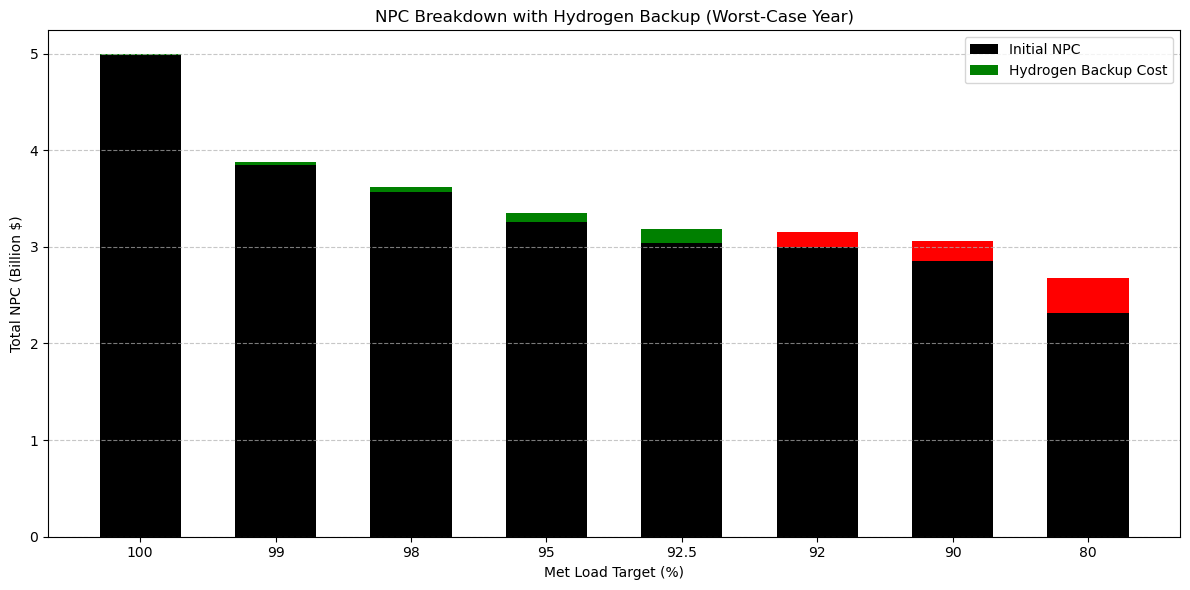

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_efficiency = 0.40
hydrogen_energy_density = 40  # kWh/kg
electrolyzer_cost_per_kw = 1500
fuel_cell_cost_per_kw = 1000
hydrogen_storage_cost_per_kg = 0.72
hours_per_year = 8760
electrolyzer_utilization_hours = 8760
fuel_cell_peak_margin = 2.0

# === Folder paths ===
folders = {
    "100": r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    "99":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    "98":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    "95":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    "92.5":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment",
    "92":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment",
    "90":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    "80":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}

# === Storage ===
metloads = []
initial_npcs = []
hydrogen_costs = []
hydrogen_sufficient_flags = []

# === Loop through each folder
for met, folder in folders.items():
    csv_path = os.path.join(folder, "capacity_and_costs_by_year.csv")
    if not os.path.exists(csv_path):
        continue

    df = pd.read_csv(csv_path)
    worst_row = df.loc[df['Total_Unmet_kWh'].idxmax()]
    unmet_kwh = worst_row['Total_Unmet_kWh']
    curtailed_kwh = worst_row['Total_Curtailed_kWh']
    base_npc = worst_row['Total_NPC']

    # Hydrogen requirement
    dc_bus_kwh = unmet_kwh / dc_efficiency
    hydrogen_input_kwh = dc_bus_kwh / hydrogen_efficiency
    hydrogen_kg = hydrogen_input_kwh / hydrogen_energy_density

    # Electrolyzer sizing
    electrolyzer_kw = hydrogen_input_kwh / electrolyzer_utilization_hours
    electrolyzer_cost = electrolyzer_kw * electrolyzer_cost_per_kw

    # Fuel cell sizing
    avg_unmet_kw = unmet_kwh / hours_per_year
    fuel_cell_kw = avg_unmet_kw * fuel_cell_peak_margin
    fuel_cell_cost = fuel_cell_kw * fuel_cell_cost_per_kw

    # Hydrogen storage
    storage_cost = hydrogen_kg * hydrogen_storage_cost_per_kg

    # Total hydrogen cost
    hydrogen_cost = electrolyzer_cost + fuel_cell_cost + storage_cost

    # Check if curtailed energy is enough
    hydrogen_sufficient = curtailed_kwh >= hydrogen_input_kwh

    # Store results
    metloads.append(met)
    initial_npcs.append(base_npc / 1e9)
    hydrogen_costs.append(hydrogen_cost / 1e9)
    hydrogen_sufficient_flags.append(hydrogen_sufficient)

# === Plotting
x = np.arange(len(metloads))
bar_width = 0.6
bar_colors = ['green' if flag else 'red' for flag in hydrogen_sufficient_flags]

plt.figure(figsize=(12, 6))
# Initial NPC bars
plt.bar(x, initial_npcs, color='black', width=bar_width, label='Initial NPC')
# Hydrogen cost bars stacked
plt.bar(x, hydrogen_costs, bottom=initial_npcs, color=bar_colors, width=bar_width, label='Hydrogen Backup Cost')

plt.xticks(x, metloads)
plt.xlabel("Met Load Target (%)")
plt.ylabel("Total NPC (Billion $)")
plt.title("NPC Breakdown with Hydrogen Backup (Worst-Case Year)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


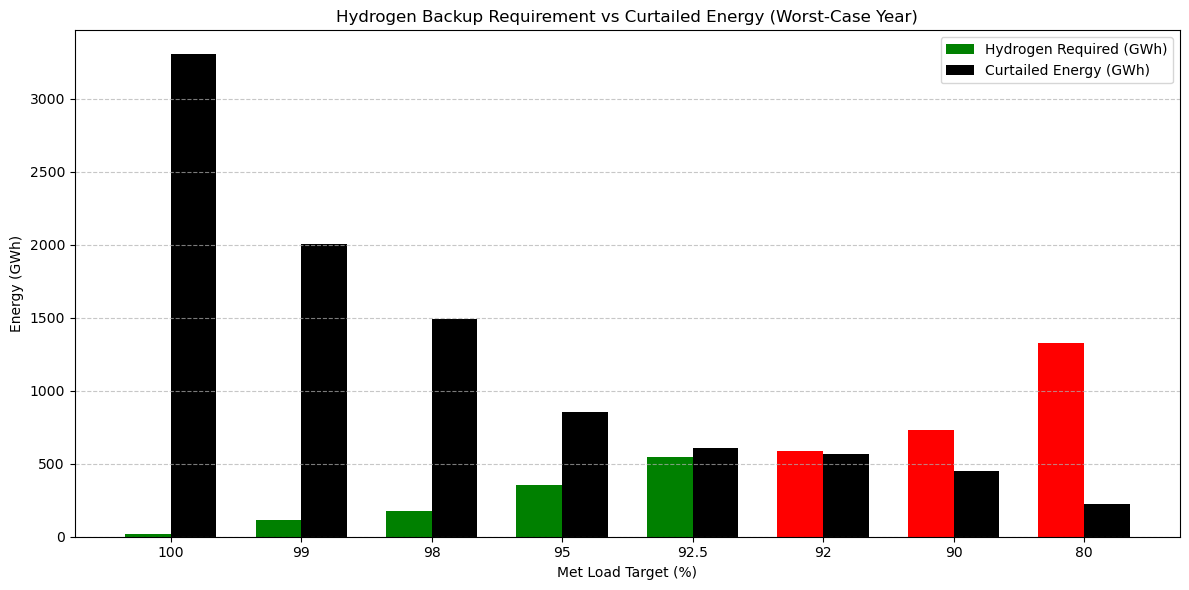

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_efficiency = 0.40
hydrogen_energy_density = 40  # kWh/kg

# === Folder paths ===
folders = {
    "100": r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    "99":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    "98":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
    "95":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_95metLoadCostCurtailment",
    "92.5":r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment",
    "92":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92metLoadCostCurtailment",
    "90":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_90metLoadCostCurtailment",
    "80":  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment",
}

# === Storage ===
metloads = []
hydrogen_kwh_required = []
curtailed_kwh_available = []
hydrogen_sufficient_flags = []

# === Loop through each folder
for met, folder in folders.items():
    csv_path = os.path.join(folder, "capacity_and_costs_by_year.csv")
    if not os.path.exists(csv_path):
        continue

    df = pd.read_csv(csv_path)
    worst_row = df.loc[df['Total_Unmet_kWh'].idxmax()]
    unmet_kwh = worst_row['Total_Unmet_kWh']
    curtailed_kwh = worst_row['Total_Curtailed_kWh']

    # Hydrogen energy input required (before fuel cell)
    dc_bus_kwh = unmet_kwh / dc_efficiency
    hydrogen_input_kwh = dc_bus_kwh / hydrogen_efficiency

    # Store results
    metloads.append(met)
    hydrogen_kwh_required.append(hydrogen_input_kwh / 1e6)  # MWh for plot
    curtailed_kwh_available.append(curtailed_kwh / 1e6)      # MWh for plot
    hydrogen_sufficient_flags.append(curtailed_kwh >= hydrogen_input_kwh)

# === Plotting
x = np.arange(len(metloads))
bar_width = 0.35
bar_colors = ['green' if flag else 'red' for flag in hydrogen_sufficient_flags]

plt.figure(figsize=(12, 6))
# Hydrogen requirement bars
plt.bar(x, hydrogen_kwh_required, color=bar_colors, width=bar_width, label='Hydrogen Required (GWh)')
# Curtailed energy bars right next to them
plt.bar(x + bar_width, curtailed_kwh_available, color='black', width=bar_width, label='Curtailed Energy (GWh)')

plt.xticks(x + bar_width / 2, metloads)
plt.xlabel("Met Load Target (%)")
plt.ylabel("Energy (GWh)")
plt.title("Hydrogen Backup Requirement vs Curtailed Energy (Worst-Case Year)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [5]:
import os
import pandas as pd

# === Folder path and year range ===
folder = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_92_5metLoadCostCurtailment"
years = range(2024, 1980 - 1, -1)

# === Storage for results ===
max_curtailment_by_year = []

# === Loop over each year's file ===
for year in years:
    file_path = os.path.join(folder, f"hourly_dispatch_{year}.csv")
    try:
        df = pd.read_csv(file_path)
        max_curtailment = df['Curtailment (kW)'].max()
        max_row = df['Curtailment (kW)'].idxmax()  # gets the index (hour) where max occurs
        max_curtailment_by_year.append({
            "Year": year,
            "Max Curtailment (kW)": max_curtailment,
            "Hour of Max Curtailment": int(max_row)
        })
    except Exception as e:
        print(f"Error reading {year}: {e}")
        max_curtailment_by_year.append({
            "Year": year,
            "Max Curtailment (kW)": None,
            "Hour of Max Curtailment": None
        })

# === Create DataFrame and sort ===
results_df = pd.DataFrame(max_curtailment_by_year).sort_values("Year", ascending=False)

# === Find overall max curtailment ===
overall_idx = results_df["Max Curtailment (kW)"].idxmax()
overall_entry = results_df.loc[overall_idx]

# === Output ===
print(results_df)
print(f"\nOverall max curtailment: {overall_entry['Max Curtailment (kW)']:.2f} kW "
      f"in year {overall_entry['Year']}, hour {overall_entry['Hour of Max Curtailment']}")


    Year  Max Curtailment (kW)  Hour of Max Curtailment
0   2024          1.329579e+06                      474
1   2023          1.319405e+06                     1866
2   2022          1.336108e+06                     1697
3   2021          1.321320e+06                     1242
4   2020          1.325731e+06                     1073
5   2019          1.374799e+06                     7578
6   2018          1.346156e+06                      378
7   2017          1.328612e+06                     1337
8   2016          1.294830e+06                     1049
9   2015          1.387242e+06                     1170
10  2014          1.378933e+06                      138
11  2013          1.342761e+06                     1193
12  2012          1.343704e+06                     1001
13  2011          1.325507e+06                     1002
14  2010          1.352007e+06                     1314
15  2009          1.387305e+06                     1433
16  2008          1.309034e+06                  

In [1]:
import os
import pandas as pd
import numpy as np

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_rt_efficiency = 0.40
total_efficiency = dc_efficiency * hydrogen_rt_efficiency  # ~0.36084

base_path = r"C:\Users\Abdullah"
sizing_year = 2024
folder = (
    os.path.join(base_path, "dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment")
    if sizing_year == 2024
    else os.path.join(base_path, f"dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment{sizing_year}")
)

# === Step 1: Find worst-case year ===
max_unmet = -1
worst_year = None
dispatch_data = {}

for year in range(1980, 2025):
    file = os.path.join(folder, f"hourly_dispatch_{year}.csv")
    df = pd.read_csv(file)
    total_unmet = df["Unmet (kW)"].sum()
    dispatch_data[year] = df
    if total_unmet > max_unmet:
        max_unmet = total_unmet
        worst_year = year

print(f"Worst-case year: {worst_year} with total unmet load = {max_unmet:.2f} kWh")

# === Step 2: Simulate hydrogen storage causally for a given electrolyzer capacity ===
df = dispatch_data[worst_year]
curtailment = df["Curtailment (kW)"].values
unmet = df["Unmet (kW)"].values
hours = len(curtailment)

def hydrogen_simulation(electrolyzer_capacity):
    h2_storage = 0.0
    for t in range(hours):
        # Electrolyzer processing from curtailment
        energy_input = min(curtailment[t], electrolyzer_capacity)
        h2_produced = energy_input * hydrogen_rt_efficiency  # kWh of H2
        h2_storage += h2_produced

        # Load to be met via fuel cell
        unmet_load = unmet[t]
        if unmet_load > 0:
            h2_needed = unmet_load / total_efficiency  # kWh needed before FC losses
            if h2_storage < h2_needed:
                return False  # cannot meet load at this hour
            h2_storage -= h2_needed
    return True

# === Step 3: Binary search for minimum electrolyzer capacity ===
low, high = 0, max(curtailment.max(), 500000)
tolerance = 0.1
best_capacity = None

while high - low > tolerance:
    mid = (low + high) / 2
    if hydrogen_simulation(mid):
        best_capacity = mid
        high = mid
    else:
        low = mid

print(f"\n✅ Minimum electrolyzer capacity required: {best_capacity:.2f} kW")
print(h2_storage)

Worst-case year: 1986 with total unmet load = 40104950.20 kWh

✅ Minimum electrolyzer capacity required: 133753.05 kW


NameError: name 'h2_storage' is not defined

In [3]:
import os
import pandas as pd
import numpy as np

# === Constants ===
dc_efficiency = 0.97 * 0.93
hydrogen_rt_efficiency = 0.40
total_efficiency = dc_efficiency * hydrogen_rt_efficiency  # ≈ 0.36084
hydrogen_energy_density = 40  # kWh per kg of hydrogen

# === Paths ===
base_path = r"C:\Users\Abdullah"
sizing_year = 2024
folder = (
    os.path.join(base_path, "dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment")
    if sizing_year == 2024
    else os.path.join(base_path, f"dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment{sizing_year}")
)

# === Step 1: Find worst-case year ===
max_unmet = -1
worst_year = None
dispatch_data = {}

for year in range(1980, 2025):
    file = os.path.join(folder, f"hourly_dispatch_{year}.csv")
    df = pd.read_csv(file)
    total_unmet = df["Unmet (kW)"].sum()
    dispatch_data[year] = df
    if total_unmet > max_unmet:
        max_unmet = total_unmet
        worst_year = year

print(f"\n📉 Worst-case year: {worst_year} with total unmet load = {max_unmet:.2f} kWh")

# === Step 2: Prepare for simulation ===
df = dispatch_data[worst_year]
curtailment = df["Curtailment (kW)"].values
unmet = df["Unmet (kW)"].values
hours = len(curtailment)

# === Step 3: Define simulation function ===
def hydrogen_simulation(electrolyzer_capacity, return_storage=False):
    h2_storage = 0.0
    max_storage = 0.0

    for t in range(hours):
        energy_input = min(curtailment[t], electrolyzer_capacity)
        h2_produced = energy_input * hydrogen_rt_efficiency
        h2_storage += h2_produced

        if h2_storage > max_storage:
            max_storage = h2_storage

        unmet_load = unmet[t]
        if unmet_load > 0:
            h2_needed = unmet_load / total_efficiency
            if h2_storage < h2_needed:
                return (False, None) if return_storage else False
            h2_storage -= h2_needed

    return (True, max_storage) if return_storage else True

# === Step 4: Binary search for minimum electrolyzer capacity ===
low, high = 0, max(curtailment.max(), 1_000_000)
tolerance = 0.1
best_capacity = None

while high - low > tolerance:
    mid = (low + high) / 2
    if hydrogen_simulation(mid):
        best_capacity = mid
        high = mid
    else:
        low = mid

# === Step 5: Final simulation with best capacity to get max storage ===
if best_capacity is not None:
    success, max_h2_storage_kwh = hydrogen_simulation(best_capacity, return_storage=True)
    if success:
        max_h2_storage_kg = max_h2_storage_kwh / hydrogen_energy_density

        print(f"\n✅ Minimum electrolyzer capacity required: {best_capacity:.2f} kW")
        print(f"📦 Maximum hydrogen storage needed: {max_h2_storage_kwh:.2f} kWh")
        print(f"⚗️  Equivalent hydrogen mass:        {max_h2_storage_kg:.2f} kg")
    else:
        print("❌ Hydrogen system failed even after binary search.")
else:
    print("❌ Binary search failed to find a feasible electrolyzer capacity.")



📉 Worst-case year: 1986 with total unmet load = 40104950.20 kWh

✅ Minimum electrolyzer capacity required: 133753.05 kW
📦 Maximum hydrogen storage needed: 89782612.09 kWh
⚗️  Equivalent hydrogen mass:        2244565.30 kg


In [3]:
import os

# Build the correct path for user's machine
folder_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment"
csv_file = os.path.join(folder_path, "capacity_and_costs_by_year.csv")

# Try loading the CSV and extracting 2024 capacities
if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    if 2024 in df["Year"].values:
        row_2024 = df[df["Year"] == 2024].iloc[0]
        fixed_solar = row_2024["Solar_Capacity_PV"]
        fixed_wind = row_2024["Wind_Capacity_HAWT"]
        fixed_battery = row_2024["Battery_Capacity_kWh"]
        result = {
            "fixed_solar": fixed_solar,
            "fixed_wind": fixed_wind,
            "fixed_battery": fixed_battery
        }
    else:
        result = {"error": "Year 2024 not found in CSV."}
else:
    result = {"error": "CSV file not found at expected path."}

result


{'fixed_solar': 7946302.2880905615,
 'fixed_wind': 134.08563138722766,
 'fixed_battery': 3862412.6431740858}

In [1]:
import numpy as np
import pandas as pd
import os
import gurobipy as gp
from gurobipy import GRB
from scipy.interpolate import make_interp_spline

# === Load base load ===
base_path = r"C:\Users\Abdullah\Desktop"
df_base = pd.read_csv(os.path.join(base_path, "base_power_profile.csv"))
base_power = df_base['Power_W'].to_numpy()
hours = 8760

quarter_midpoints = np.linspace(0, hours, 5)
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]
hourly_pue = make_interp_spline(quarter_midpoints, pue_targets, k=3)(np.arange(hours))
dc_ac_conversion_efficiency = 0.975
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)

# === Load fixed capacities from 2024 ===
def load_2024_capacities():
    csv_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment\capacity_and_costs_by_year.csv"
    df = pd.read_csv(csv_path)
    row = df[df["Year"] == 2024].iloc[0]
    return row["Solar_Capacity_PV"], row["Wind_Capacity_HAWT"], row["Battery_Capacity_kWh"]

# === Rainflow degradation tracker ===
def calculate_rainflow_degradation_verbose(soc_series, capacity, A=0.000144, beta=1.79, dod_threshold=0):
    soc_series = np.array(soc_series)
    total_degradation = 0.0
    cycle_info = []
    peak = soc_series[0]
    valley = peak
    direction = None
    peak_hour = 0
    valley_hour = 0

    for i in range(1, len(soc_series)):
        if soc_series[i] > soc_series[i - 1]:
            if direction == 'down':
                dod = (peak - valley) / capacity if capacity > 0 else 0
                if dod >= dod_threshold:
                    degradation = A * (dod ** beta)
                    total_degradation += degradation
                    cycle_info.append({"type": "discharge", "peak_hour": peak_hour, "valley_hour": valley_hour, "DoD": round(dod, 4), "degradation": round(degradation, 6)})
                peak = soc_series[i]
                peak_hour = i
                direction = 'up'
            else:
                peak = max(peak, soc_series[i])
                if peak == soc_series[i]:
                    peak_hour = i
                direction = 'up'
        elif soc_series[i] < soc_series[i - 1]:
            if direction == 'up':
                valley = soc_series[i]
                valley_hour = i
                direction = 'down'
            else:
                valley = min(valley, soc_series[i])
                if valley == soc_series[i]:
                    valley_hour = i
                direction = 'down'

    return cycle_info, total_degradation

# === Dispatch Simulation ===
def simulate_dispatch_fixed_capacities_with_hydrogen(load_profile, solar_resource, wind_resource,
                                                     electrolyzer_capacity, fuel_cell_capacity,
                                                     hydrogen_storage_capacity,
                                                     battery_efficiency=0.89,
                                                     hydrogen_rt_efficiency=0.40,
                                                     dc_efficiency=0.97 * 0.93):# ,initial_soc=fixed_battery

    fixed_solar, fixed_wind, fixed_battery = load_2024_capacities()
    initial_soc=fixed_battery
    hours = len(load_profile)
    model = gp.Model("dispatch_with_hydrogen")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 300

    battery_charge = model.addVars(hours, lb=0, name="charge")
    battery_discharge = model.addVars(hours, lb=0, name="discharge")
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery, name="soc")
    unmet_load = model.addVars(hours, lb=0, name="unmet")
    curtailment = model.addVars(hours, lb=0, name="curtailment")
    h2_storage = model.addVars(hours, lb=0, ub=hydrogen_storage_capacity, name="h2_storage")
    h2_charge = model.addVars(hours, lb=0, ub=electrolyzer_capacity, name="h2_charge")
    h2_discharge = model.addVars(hours, lb=0, ub=fuel_cell_capacity, name="h2_discharge")

    model.addConstr(battery_soc[0] == initial_soc)
    model.addConstr(h2_storage[0] == 0)


    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(
            net_gen +
            battery_discharge[t] * dc_efficiency +
            h2_discharge[t] * dc_efficiency -
            battery_charge[t] / battery_efficiency -
            h2_charge[t] -
            curtailment[t] -
            load_profile[t] +
            unmet_load[t] == 0)

        if t > 0:
            model.addConstr(
                battery_soc[t] == battery_soc[t - 1] +
                battery_charge[t] - battery_discharge[t] / battery_efficiency)

            model.addConstr(
                h2_storage[t] == h2_storage[t - 1] +
                h2_charge[t] -
                h2_discharge[t] / hydrogen_rt_efficiency)

        model.addConstr(battery_discharge[t] <= battery_soc[t])

    model.addConstr(battery_soc[hours - 1] >= 0)
    model.addConstr(h2_storage[hours - 1] >= 0)
    model.setObjective(gp.quicksum(unmet_load[t] for t in range(hours)), GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return {
            "total_unmet": sum(unmet_load[t].X for t in range(hours))
        }
    else:
        return None

# === Define hydrogen system parameters ===
electrolyzer_capacity = 0#133753.06      # kW
fuel_cell_capacity = 0#270000         # kW
hydrogen_storage_capacity = 0#89782612.09-100     # kWh

# === Run dispatch across 1980–2024 ===
unmet_across_years = {}
for year in range(2024, 1979, -1):
    try:
        if year >= 2000:
            idx = 2024 - year
            solar_csv = fr"{base_path}\Solar\2000s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
            wind_csv = fr"{base_path}\Wind\2000s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"
        else:
            idx = year - 1900
            solar_csv = fr"{base_path}\Solar\1900s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
            wind_csv = fr"{base_path}\Wind\1900s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"

        df_solar = pd.read_csv(solar_csv, skiprows=3)
        df_wind = pd.read_csv(wind_csv, skiprows=3)
        solar_resource = df_solar['electricity'].values[:hours]
        wind_resource = df_wind['electricity'].values[:hours]

        result = simulate_dispatch_fixed_capacities_with_hydrogen(
            load_profile=load_profile,
            solar_resource=solar_resource,
            wind_resource=wind_resource,
            electrolyzer_capacity=electrolyzer_capacity,
            fuel_cell_capacity=fuel_cell_capacity,
            hydrogen_storage_capacity=hydrogen_storage_capacity
        )

        unmet_across_years[year] = result['total_unmet'] if result else None
        print(f"Year {year}: {'✅' if result else '❌'} {result['total_unmet']:.2f} kWh" if result else f"Year {year}: ❌ Optimization failed")

    except Exception as e:
        unmet_across_years[year] = None
        print(f"Year {year}: ❌ Exception occurred - {e}")

# === Print final summary ===
print("\n=== Hydrogen-Aware Dispatch Unmet Load Summary ===")
for year in range(2024, 1979, -1):
    val = unmet_across_years[year]
    print(f"Year {year}: {'❌ Failed' if val is None else f'✅ {val:.2f} kWh'}")

Set parameter Username
Set parameter LicenseID to value 2667226
Academic license - for non-commercial use only - expires 2026-05-16
Year 2024: ✅ 18165054.79 kWh
Year 2023: ✅ 14484044.83 kWh
Year 2022: ✅ 19374198.10 kWh
Year 2021: ✅ 9270965.09 kWh
Year 2020: ✅ 25611424.16 kWh
Year 2019: ✅ 33988118.88 kWh
Year 2018: ✅ 21220717.13 kWh
Year 2017: ✅ 28700851.07 kWh
Year 2016: ✅ 26515239.13 kWh
Year 2015: ✅ 36142619.27 kWh
Year 2014: ✅ 25667693.62 kWh
Year 2013: ✅ 23089849.43 kWh
Year 2012: ✅ 17657215.44 kWh
Year 2011: ✅ 22329766.16 kWh
Year 2010: ✅ 12299017.39 kWh
Year 2009: ✅ 21581660.38 kWh
Year 2008: ✅ 16145351.20 kWh
Year 2007: ✅ 22317215.48 kWh
Year 2006: ✅ 20271259.81 kWh
Year 2005: ✅ 21056813.28 kWh
Year 2004: ✅ 20761855.18 kWh
Year 2003: ✅ 21398632.13 kWh
Year 2002: ✅ 21255388.51 kWh
Year 2001: ✅ 27679524.80 kWh
Year 2000: ✅ 16106959.37 kWh
Year 1999: ✅ 12687462.94 kWh
Year 1998: ✅ 34987278.65 kWh
Year 1997: ✅ 21168666.03 kWh
Year 1996: ✅ 24812878.55 kWh
Year 1995: ✅ 7232512.58 kWh


In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
from scipy.interpolate import make_interp_spline

# === Load base load ===
base_path = r"C:\Users\Abdullah\Desktop"
df_base = pd.read_csv(os.path.join(base_path, "base_power_profile.csv"))
base_power = df_base['Power_W'].to_numpy()
hours = 8760

quarter_midpoints = np.linspace(0, hours, 5)
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]
hourly_pue = make_interp_spline(quarter_midpoints, pue_targets, k=3)(np.arange(hours))
dc_ac_conversion_efficiency = 0.975
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)

# === Load fixed capacities from 2024 ===
def load_2024_capacities():
    csv_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment\capacity_and_costs_by_year.csv"
    df = pd.read_csv(csv_path)
    row = df[df["Year"] == 2024].iloc[0]
    return row["Solar_Capacity_PV"], row["Wind_Capacity_HAWT"], row["Battery_Capacity_kWh"]

# === Identify year with highest unmet load ===
def find_worst_year():
    dispatch_dir = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment"
    max_unmet = 0
    worst_year = 1980
    
    for year in range(1980, 2025):
        file_name = f"hourly_dispatch_{year}.csv"
        file_path = os.path.join(dispatch_dir, file_name)
        
        if not os.path.exists(file_path):
            print(f"Warning: File {file_name} not found. Skipping year {year}.")
            continue
        
        try:
            df = pd.read_csv(file_path, usecols=['Unmet (kW)'])
            total_unmet = df['Unmet (kW)'].sum()
            if total_unmet > max_unmet:
                max_unmet = total_unmet
                worst_year = year
            print(f"Year {year}: Total Unmet Load = {total_unmet:.2f} kWh")
        except ValueError as e:
            print(f"Error: Column 'Unmet (kW)' not found in {file_name}. Skipping year {year}.")
            continue
        except Exception as e:
            print(f"Error reading {file_name}: {str(e)}. Skipping year {year}.")
            continue
    
    if max_unmet == 0:
        raise ValueError("No valid data found for 'Unmet (kW)' in any year.")
    
    return worst_year, max_unmet

# === Dispatch Simulation ===
def simulate_dispatch_fixed_capacities_with_hydrogen(load_profile, solar_resource, wind_resource,
                                                    electrolyzer_capacity, fuel_cell_capacity,
                                                    hydrogen_storage_capacity,
                                                    battery_efficiency=0.89,
                                                    hydrogen_rt_efficiency=0.40,
                                                    dc_efficiency=0.97 * 0.93):
    fixed_solar, fixed_wind, fixed_battery = load_2024_capacities()
    initial_soc = fixed_battery
    hours = len(load_profile)
    model = gp.Model("dispatch_with_hydrogen")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 300

    battery_charge = model.addVars(hours, lb=0, name="charge")
    battery_discharge = model.addVars(hours, lb=0, name="discharge")
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery, name="soc")
    unmet_load = model.addVars(hours, lb=0, name="unmet")
    curtailment = model.addVars(hours, lb=0, name="curtailment")
    h2_storage = model.addVars(hours, lb=0, ub=hydrogen_storage_capacity, name="h2_storage")
    h2_charge = model.addVars(hours, lb=0, ub=electrolyzer_capacity, name="h2_charge")
    h2_discharge = model.addVars(hours, lb=0, ub=fuel_cell_capacity, name="h2_discharge")

    model.addConstr(battery_soc[0] == initial_soc)
    model.addConstr(h2_storage[0] == 0)

    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(
            net_gen +
            battery_discharge[t] * dc_efficiency +
            h2_discharge[t] * dc_efficiency -
            battery_charge[t] / battery_efficiency -
            h2_charge[t] -
            curtailment[t] -
            load_profile[t] +
            unmet_load[t] == 0)

        if t > 0:
            model.addConstr(
                battery_soc[t] == battery_soc[t - 1] +
                battery_charge[t] - battery_discharge[t] / battery_efficiency)

            model.addConstr(
                h2_storage[t] == h2_storage[t - 1] +
                h2_charge[t] -
                h2_discharge[t] / hydrogen_rt_efficiency)

        model.addConstr(battery_discharge[t] <= battery_soc[t])

    model.addConstr(battery_soc[hours - 1] >= 0)
    model.addConstr(h2_storage[hours - 1] >= 0)
    model.setObjective(gp.quicksum(unmet_load[t] for t in range(hours)), GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return {
            "total_unmet": sum(unmet_load[t].X for t in range(hours))
        }
    else:
        return None

# === Minimize Electrolyzer and Hydrogen Storage Capacity ===
def minimize_hydrogen_system(worst_year, max_unmet_load):
    # Load solar and wind resources for the worst year
    if worst_year >= 2000:
        idx = 2024 - worst_year
        solar_csv = fr"C:\Users\Abdullah\Desktop\Solar\2000s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
        wind_csv = fr"C:\Users\Abdullah\Desktop\Wind\2000s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"
    else:
        idx = worst_year - 1900
        solar_csv = fr"C:\Users\Abdullah\Desktop\Solar\1900s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
        wind_csv = fr"C:\Users\Abdullah\Desktop\Wind\1900s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"

    df_solar = pd.read_csv(solar_csv, skiprows=3)
    df_wind = pd.read_csv(wind_csv, skiprows=3)
    solar_resource = df_solar['electricity'].values[:hours]
    wind_resource = df_wind['electricity'].values[:hours]

    # Binary search to minimize electrolyzer capacity
    elec_min, elec_max = 0, 500000  # kW (adjust max as needed)
    h2_storage_min, h2_storage_max = 0, 100000000  # kWh (adjust max as needed)
    tolerance = 1e-3  # Unmet load tolerance in kWh
    best_electrolyzer = elec_max
    best_h2_storage = h2_storage_max

    while elec_max - elec_min > 1:
        elec_mid = (elec_min + elec_max) / 2
        # Assume fuel cell capacity equals electrolyzer capacity for simplicity
        fuel_cell_mid = elec_mid

        # Binary search for hydrogen storage
        h2_min, h2_max = h2_storage_min, h2_storage_max
        while h2_max - h2_min > 1:
            h2_mid = (h2_min + h2_max) / 2
            result = simulate_dispatch_fixed_capacities_with_hydrogen(
                load_profile=load_profile,
                solar_resource=solar_resource,
                wind_resource=wind_resource,
                electrolyzer_capacity=elec_mid,
                fuel_cell_capacity=fuel_cell_mid,
                hydrogen_storage_capacity=h2_mid
            )

            if result and result['total_unmet'] <= tolerance:
                h2_max = h2_mid
                best_h2_storage = min(best_h2_storage, h2_mid)
            else:
                h2_min = h2_mid

        # If the smallest h2_storage worked, reduce electrolyzer capacity
        result = simulate_dispatch_fixed_capacities_with_hydrogen(
            load_profile=load_profile,
            solar_resource=solar_resource,
            wind_resource=wind_resource,
            electrolyzer_capacity=elec_mid,
            fuel_cell_capacity=elec_mid,
            hydrogen_storage_capacity=best_h2_storage
        )

        if result and result['total_unmet'] <= tolerance:
            elec_max = elec_mid
            best_electrolyzer = min(best_electrolyzer, elec_mid)
        else:
            elec_min = elec_mid

    return best_electrolyzer, best_electrolyzer, best_h2_storage  # Assuming fuel_cell_capacity = electrolyzer_capacity

# === Main Execution ===
def main():
    # Step 1: Find the worst year
    worst_year, max_unmet = find_worst_year()
    print(f"Worst year: {worst_year} with unmet load: {max_unmet:.2f} kWh")

    # Step 2: Minimize hydrogen system capacities
    electrolyzer_capacity, fuel_cell_capacity, hydrogen_storage_capacity = minimize_hydrogen_system(worst_year, max_unmet)
    print(f"\nOptimized Hydrogen System Capacities for Year {worst_year}:")
    print(f"Electrolyzer Capacity: {electrolyzer_capacity:.2f} kW")
    print(f"Fuel Cell Capacity: {fuel_cell_capacity:.2f} kW")
    print(f"Hydrogen Storage Capacity: {hydrogen_storage_capacity:.2f} kWh")

    # Verify the solution
    if worst_year >= 2000:
        idx = 2024 - worst_year
        solar_csv = fr"C:\Users\Abdullah\Desktop\Solar\2000s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
        wind_csv = fr"C:\Users\Abdullah\Desktop\Wind\2000s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"
    else:
        idx = worst_year - 1900
        solar_csv = fr"C:\Users\Abdullah\Desktop\Solar\1900s\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
        wind_csv = fr"C:\Users\Abdullah\Desktop\Wind\1900s\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"

    df_solar = pd.read_csv(solar_csv, skiprows=3)
    df_wind = pd.read_csv(wind_csv, skiprows=3)
    solar_resource = df_solar['electricity'].values[:hours]
    wind_resource = df_wind['electricity'].values[:hours]

    result = simulate_dispatch_fixed_capacities_with_hydrogen(
        load_profile=load_profile,
        solar_resource=solar_resource,
        wind_resource=wind_resource,
        electrolyzer_capacity=electrolyzer_capacity,
        fuel_cell_capacity=fuel_cell_capacity,
        hydrogen_storage_capacity=hydrogen_storage_capacity
    )

    print(f"\nVerification for Year {worst_year}:")
    print(f"Unmet Load: {result['total_unmet']:.2f} kWh" if result else "Optimization failed")

if __name__ == "__main__":
    main()

Year 1980: Total Unmet Load = 28599501.72 kWh
Year 1981: Total Unmet Load = 26332400.14 kWh
Year 1982: Total Unmet Load = 22639139.42 kWh
Year 1983: Total Unmet Load = 36299877.25 kWh
Year 1984: Total Unmet Load = 16018152.71 kWh
Year 1985: Total Unmet Load = 25117060.27 kWh
Year 1986: Total Unmet Load = 40104950.20 kWh
Year 1987: Total Unmet Load = 25903286.36 kWh
Year 1988: Total Unmet Load = 9695515.26 kWh
Year 1989: Total Unmet Load = 24996850.32 kWh
Year 1990: Total Unmet Load = 23395060.98 kWh
Year 1991: Total Unmet Load = 32735783.14 kWh
Year 1992: Total Unmet Load = 31124388.74 kWh
Year 1993: Total Unmet Load = 31008006.88 kWh
Year 1994: Total Unmet Load = 32723402.58 kWh
Year 1995: Total Unmet Load = 7232512.58 kWh
Year 1996: Total Unmet Load = 24812878.61 kWh
Year 1997: Total Unmet Load = 21168666.03 kWh
Year 1998: Total Unmet Load = 34987278.62 kWh
Year 1999: Total Unmet Load = 12687462.94 kWh
Year 2000: Total Unmet Load = 16106959.37 kWh
Year 2001: Total Unmet Load = 276795

In [ ]:
import numpy as np
import pandas as pd
import os
import gurobipy as gp
from gurobipy import GRB
from scipy.interpolate import make_interp_spline

# === Load base load ===
base_path = r"C:\Users\Abdullah\Desktop"
df_base = pd.read_csv(os.path.join(base_path, "base_power_profile.csv"))
base_power = df_base['Power_W'].to_numpy()
hours = 8760

quarter_midpoints = np.linspace(0, hours, 5)
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]
hourly_pue = make_interp_spline(quarter_midpoints, pue_targets, k=3)(np.arange(hours))
dc_ac_conversion_efficiency = 0.975
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)

# === Load fixed capacities from 2024 ===
def load_2024_capacities():
    csv_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment\capacity_and_costs_by_year.csv"
    df = pd.read_csv(csv_path)
    row = df[df["Year"] == 2024].iloc[0]
    return row["Solar_Capacity_PV"], row["Wind_Capacity_HAWT"], row["Battery_Capacity_kWh"]

# === Load solar and wind ===
def load_resource_data(year):
    idx = 2024 - year if year >= 2000 else year - 1900
    solar_csv = fr"{base_path}\Solar\{'2000s' if year >= 2000 else '1900s'}\ninja_pv_35.1460_-90.0518_uncorrected ({idx}).csv"
    wind_csv = fr"{base_path}\Wind\{'2000s' if year >= 2000 else '1900s'}\ninja_wind_35.1460_-90.0518_uncorrected ({idx}).csv"
    df_solar = pd.read_csv(solar_csv, skiprows=3)
    df_wind = pd.read_csv(wind_csv, skiprows=3)
    return df_solar['electricity'].values[:hours], df_wind['electricity'].values[:hours]

# === Identify worst-case year ===
def find_worst_year():
    worst_year = None
    max_unmet = -1
    for year in range(1980, 2025):
        folder = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dcNevada" if year == 2024 else rf"C:\Users\Abdullah\dispatch_outputs_solar-wind_dcNevada{year}"
        file = os.path.join(folder, f"hourly_dispatch_{year}.csv")
        if not os.path.exists(file):
            continue
        df = pd.read_csv(file)
        total_unmet = df["Unmet (kW)"].sum()
        if total_unmet > max_unmet:
            max_unmet = total_unmet
            worst_year = year
    return worst_year

# === Optimization for worst year ===
def optimize_electrolyzer_and_storage(load_profile, solar_resource, wind_resource,
                                      fuel_cell_capacity,
                                      battery_efficiency=0.89,
                                      hydrogen_rt_efficiency=0.40,
                                      dc_efficiency=0.97 * 0.93,
                                      initial_soc=0):

    fixed_solar, fixed_wind, fixed_battery = load_2024_capacities()
    hours = len(load_profile)
    model = gp.Model("min_electrolyzer_and_h2")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 600

    # === Variables ===
    electrolyzer_capacity = model.addVar(lb=0, name="electrolyzer_capacity")
    hydrogen_storage_capacity = model.addVar(lb=0, name="hydrogen_storage_capacity")

    battery_charge = model.addVars(hours, lb=0, name="charge")
    battery_discharge = model.addVars(hours, lb=0, name="discharge")
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery, name="soc")
    unmet_load = model.addVars(hours, lb=0, name="unmet")
    curtailment = model.addVars(hours, lb=0, name="curtailment")
    h2_storage = model.addVars(hours, lb=0, name="h2_storage")
    h2_charge = model.addVars(hours, lb=0, name="h2_charge")
    h2_discharge = model.addVars(hours, lb=0, ub=fuel_cell_capacity, name="h2_discharge")

    model.addConstr(battery_soc[0] == initial_soc)
    model.addConstr(h2_storage[0] == hydrogen_storage_capacity)

    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(
            net_gen +
            battery_discharge[t] * dc_efficiency +
            h2_discharge[t] * dc_efficiency -
            battery_charge[t] / battery_efficiency -
            h2_charge[t] -
            curtailment[t] -
            load_profile[t] +
            unmet_load[t] == 0)

        if t > 0:
            model.addConstr(
                battery_soc[t] == battery_soc[t - 1] +
                battery_charge[t] - battery_discharge[t] / battery_efficiency)

            model.addConstr(
                h2_storage[t] == h2_storage[t - 1] +
                h2_charge[t] * hydrogen_rt_efficiency -
                h2_discharge[t] / hydrogen_rt_efficiency)

        model.addConstr(battery_discharge[t] <= battery_soc[t])
        model.addConstr(h2_charge[t] <= electrolyzer_capacity)
        model.addConstr(h2_storage[t] <= hydrogen_storage_capacity)

    model.addConstr(battery_soc[hours - 1] >= 0)
    model.addConstr(h2_storage[hours - 1] >= 0)

    model.setObjective(electrolyzer_capacity + hydrogen_storage_capacity / 1e5, GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return {
            "electrolyzer_capacity": electrolyzer_capacity.X,
            "hydrogen_storage_capacity": hydrogen_storage_capacity.X
        }
    else:
        return None

# === Simulate unmet load using fixed hydrogen system ===
def simulate_with_fixed_hydrogen(load_profile, solar_resource, wind_resource,
                                 electrolyzer_capacity, hydrogen_storage_capacity, fuel_cell_capacity,
                                 battery_efficiency=0.89,
                                 hydrogen_rt_efficiency=0.40,
                                 dc_efficiency=0.97 * 0.93,
                                 initial_soc=0):

    fixed_solar, fixed_wind, fixed_battery = load_2024_capacities()
    hours = len(load_profile)
    model = gp.Model("test_fixed_h2")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = 300

    battery_charge = model.addVars(hours, lb=0)
    battery_discharge = model.addVars(hours, lb=0)
    battery_soc = model.addVars(hours, lb=0, ub=fixed_battery)
    unmet_load = model.addVars(hours, lb=0)
    curtailment = model.addVars(hours, lb=0)
    h2_storage = model.addVars(hours, lb=0, ub=hydrogen_storage_capacity)
    h2_charge = model.addVars(hours, lb=0, ub=electrolyzer_capacity)
    h2_discharge = model.addVars(hours, lb=0, ub=fuel_cell_capacity)

    model.addConstr(battery_soc[0] == initial_soc)
    model.addConstr(h2_storage[0] == hydrogen_storage_capacity)

    for t in range(hours):
        solar_gen = solar_resource[t] * fixed_solar * dc_efficiency
        wind_gen = wind_resource[t] * fixed_wind * dc_efficiency
        net_gen = solar_gen + wind_gen

        model.addConstr(
            net_gen +
            battery_discharge[t] * dc_efficiency +
            h2_discharge[t] * dc_efficiency -
            battery_charge[t] / battery_efficiency -
            h2_charge[t] -
            curtailment[t] -
            load_profile[t] +
            unmet_load[t] == 0)

        if t > 0:
            model.addConstr(battery_soc[t] == battery_soc[t - 1] + battery_charge[t] - battery_discharge[t] / battery_efficiency)
            model.addConstr(h2_storage[t] == h2_storage[t - 1] + h2_charge[t] * hydrogen_rt_efficiency - h2_discharge[t] / hydrogen_rt_efficiency)

        model.addConstr(battery_discharge[t] <= battery_soc[t])

    model.setObjective(gp.quicksum(unmet_load[t] for t in range(hours)), GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return model.ObjVal
    else:
        return None

# === Run optimization on worst-case year ===
worse_year = find_worst_year()
print(f"Worst-case year is {worse_year}")
solar_worst, wind_worst = load_resource_data(worse_year)
fuel_cell_capacity = 240000 / 0.9021

opt_result = optimize_electrolyzer_and_storage(
    load_profile=load_profile,
    solar_resource=solar_worst,
    wind_resource=wind_worst,
    fuel_cell_capacity=fuel_cell_capacity
)

if opt_result:
    print(f"\n✅ Optimal Electrolyzer Capacity: {opt_result['electrolyzer_capacity']:.2f} kW")
    print(f"✅ Optimal Hydrogen Storage: {opt_result['hydrogen_storage_capacity']:.2f} kWh")

    # === Now test across all years with fixed capacities ===
    results = []
    for year in range(2024, 1979, -1):
        try:
            solar_y, wind_y = load_resource_data(year)
            unmet_kwh = simulate_with_fixed_hydrogen(
                load_profile=load_profile,
                solar_resource=solar_y,
                wind_resource=wind_y,
                electrolyzer_capacity=opt_result['electrolyzer_capacity'],
                hydrogen_storage_capacity=opt_result['hydrogen_storage_capacity'],
                fuel_cell_capacity=fuel_cell_capacity
            )
            results.append({"Year": year, "Unmet_kWh": unmet_kwh})
            print(f"Year {year} ✅ Unmet Load: {unmet_kwh:.2f} kWh")
        except:
            results.append({"Year": year, "Unmet_kWh": None})
            print(f"Year {year} ❌ Failed to simulate")

    df_summary = pd.DataFrame(results)
    df_summary.to_csv(os.path.join(base_path, "hydrogen_unmet_by_year.csv"), index=False)
    print("\n✅ Saved hydrogen unmet load summary to CSV.")
else:
    print("❌ Optimization on worst-case year failed.")


Worst-case year is 2012
Set parameter Username
Set parameter LicenseID to value 2667226
Academic license - for non-commercial use only - expires 2026-05-16

✅ Optimal Electrolyzer Capacity: 0.00 kW
✅ Optimal Hydrogen Storage: 0.00 kWh
Year 2024 ✅ Unmet Load: 19821839.54 kWh
Year 2023 ✅ Unmet Load: 16136552.45 kWh
Year 2022 ✅ Unmet Load: 20232259.97 kWh
Year 2021 ✅ Unmet Load: 10393720.43 kWh
Year 2020 ✅ Unmet Load: 28229324.15 kWh
Year 2019 ✅ Unmet Load: 35914373.02 kWh
Year 2018 ✅ Unmet Load: 22362974.95 kWh
Year 2017 ✅ Unmet Load: 31801862.34 kWh
Year 2016 ✅ Unmet Load: 28852539.11 kWh
Year 2015 ✅ Unmet Load: 39243630.52 kWh
Year 2014 ✅ Unmet Load: 27643687.42 kWh
Year 2013 ✅ Unmet Load: 26190860.79 kWh
Year 2012 ✅ Unmet Load: 18101850.12 kWh
Year 2011 ✅ Unmet Load: 23795529.95 kWh
Year 2010 ✅ Unmet Load: 13893473.45 kWh
Year 2009 ✅ Unmet Load: 23305283.77 kWh
Year 2008 ✅ Unmet Load: 17147631.48 kWh
Year 2007 ✅ Unmet Load: 23576921.38 kWh
Year 2006 ✅ Unmet Load: 21306697.35 kWh
Year 